In [1]:
"""
Fragment 1 — Data Loading
==========================
ResNet101 Hybrid Pipeline — Feature Extraction + ML Classification

- Loads train, val and test data from disk
- Augmented folder already exists — no new augmentation
- Uses ResNet preprocess_input to match training preprocessing
- All three sets loaded here since feature extraction
  requires passing images through ResNet101 once
- Features will be extracted in Fragment 2 and saved to disk
"""

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")   # shared augmented folder
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Safety Guards ─────────────────────────────────────────────────────────────

assert os.path.exists(AUG_DIR), \
    f"Augmented folder not found: {AUG_DIR}"
assert os.path.exists(VALID_DIR), \
    f"Validation folder not found: {VALID_DIR}"
assert os.path.exists(TEST_DIR), \
    f"Test folder not found: {TEST_DIR}"

# ── Step 1: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str, test_dir: str):
    """
    Builds generators for all three sets.
    All use ResNet preprocess_input — ResNet101 shares the
    same preprocessing pipeline as ResNet50, converting RGB
    to BGR and zero-centering each channel with respect to
    the ImageNet dataset. preprocess_input imported from
    tensorflow.keras.applications.resnet (not resnet50)
    to correctly match ResNet101.
    shuffle=False on all sets — critical for correct label
    alignment when extracting features batch by batch.
    """

    # ── Train generator ──
    train_datagen   = ImageDataGenerator(preprocessing_function=preprocess_input)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,    # must be False for feature extraction
    )

    # ── Val generator ──
    valid_datagen   = ImageDataGenerator(preprocessing_function=preprocess_input)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    # ── Test generator ──
    test_datagen   = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    return train_generator, valid_generator, test_generator

# ── Step 2: Run and Summarise ─────────────────────────────────────────────────

train_generator, valid_generator, test_generator = build_generators(
    AUG_DIR, VALID_DIR, TEST_DIR
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Fragment 1 — Data Generators Ready")
print("=" * 60)
print(f"  Pipeline      : ResNet101 + SVM / KNN (Hybrid)")
print(f"  Train source  : augmented/   (shared, no new aug)")
print(f"  Valid source  : val/")
print(f"  Test source   : test/")
print(f"  Preprocessing : ResNet preprocess_input")
print(f"                  (BGR conversion + ImageNet mean subtraction)")
print(f"  Shuffle       : False on all sets (required for")
print(f"                  correct label alignment)")
print(f"  Train samples : {train_generator.samples}")
print(f"  Valid samples : {valid_generator.samples}")
print(f"  Test samples  : {test_generator.samples}")
print(f"  Classes ({NUM_CLASSES})  : {CLASS_NAMES}")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     train_generator, valid_generator and test_generator are ready.")
print("     Proceed to Fragment 2 — ResNet101 Feature Extraction.\n")


Found 8833 images belonging to 11 classes.
Found 644 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  Fragment 1 — Data Generators Ready
  Pipeline      : ResNet101 + SVM / KNN (Hybrid)
  Train source  : augmented/   (shared, no new aug)
  Valid source  : val/
  Test source   : test/
  Preprocessing : ResNet preprocess_input
                  (BGR conversion + ImageNet mean subtraction)
  Shuffle       : False on all sets (required for
                  correct label alignment)
  Train samples : 8833
  Valid samples : 644
  Test samples  : 658
  Classes (11)  : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']
  Image size    : (224, 224)
  Batch size    : 32

  ✓ Fragment 1 complete.
     train_generator, valid_generator and test_generator are ready.
     Proceed to Fragment 2 — ResNet101 Feature Extraction.



In [2]:
"""
Fragment 2 — ResNet101 Feature Extraction
==========================================
ResNet101 Hybrid Pipeline — Feature Extraction + ML Classification

- Loads ResNet101 with ImageNet weights
- Removes classification head — keeps convolutional base only
- Uses GlobalAveragePooling2D to produce 2048 features per image
- Passes all three sets through ResNet101 to extract features
- Features saved to disk as .npy files for reuse
- Extracted features passed to Fragment 3 (SVM) and
  Fragment 4 (KNN) without rerunning ResNet101
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

SAVE_DIR    = r"D:\Mold Studies\Models"
FEATURE_DIR = os.path.join(SAVE_DIR, "features", "resnet101")

os.makedirs(FEATURE_DIR, exist_ok=True)

# ── Step 1: Build ResNet101 Feature Extractor ─────────────────────────────────

def build_feature_extractor():
    """
    Loads ResNet101 with ImageNet weights and removes the
    classification head entirely.

    ResNet101 base output shape  : (7, 7, 2048)
    After GlobalAveragePooling2D : (2048,) features per image

    ResNet101 produces the same 2048-dimensional feature
    vector as ResNet50 after GAP — however the features
    are richer because ResNet101 has 101 layers vs 50,
    giving it deeper residual blocks that capture more
    complex and abstract feature hierarchies. This makes
    ResNet101 the deepest and most expressive extractor
    in this hybrid pipeline series.

    All layers are frozen — ResNet101 is used purely as a
    fixed feature extractor, not trained further.
    BatchNorm layers intentionally kept frozen — ResNet
    uses BatchNorm after every convolution and unfreezing
    them causes training instability.
    """

    base_model = ResNet101(
        input_shape = IMG_SHAPE,
        include_top = False,        # remove ImageNet classifier
        weights     = "imagenet"    # load ImageNet weights
    )

    # Freeze all layers — feature extractor only
    base_model.trainable = False

    # GlobalAveragePooling2D reduces (7, 7, 2048) → (2048,)
    x      = base_model.output
    output = GlobalAveragePooling2D(name="gap")(x)

    feature_extractor = Model(
        inputs  = base_model.input,
        outputs = output,
        name    = "resnet101_feature_extractor"
    )

    return feature_extractor, base_model

feature_extractor, base_model = build_feature_extractor()

# ── Summary ───────────────────────────────────────────────────────────────────

total_params     = feature_extractor.count_params()
trainable_params = sum(tf.size(w).numpy() for w in feature_extractor.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in feature_extractor.non_trainable_weights)

print("=" * 60)
print("  Fragment 2 — ResNet101 Feature Extractor")
print("=" * 60)
print(f"  Architecture     : ResNet101")
print(f"  Weights          : ImageNet ✓")
print(f"  Input shape      : {IMG_SHAPE}")
print(f"  Base output      : (7, 7, 2048)")
print(f"  After GAP        : 2048 features per image")
print(f"  Total base layers: {len(base_model.layers)}")
print(f"  All layers frozen: ✓")
print(f"  BatchNorm frozen : ✓ (after every convolution)")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable        : {trainable_params:,}")
print(f"  Frozen           : {frozen_params:,}")
print("=" * 60)

# ── Step 2: Feature Extraction Function ──────────────────────────────────────

def extract_features(generator, feature_extractor, set_name):
    """
    Passes all images through the ResNet101 feature extractor.
    Returns feature matrix X and label array y.
    Generator must have shuffle=False for correct alignment.
    Features saved to disk as .npy files.
    If features already exist on disk they are loaded
    instead of recomputed — safe to rerun.
    """

    feat_path  = os.path.join(FEATURE_DIR, f"X_{set_name}.npy")
    label_path = os.path.join(FEATURE_DIR, f"y_{set_name}.npy")

    # ── Load from disk if already extracted ───────────────────────────────────
    if os.path.exists(feat_path) and os.path.exists(label_path):
        print(f"  ✓ {set_name:<8} — loading from disk")
        X = np.load(feat_path)
        y = np.load(label_path)
        return X, y

    # ── Extract features ──────────────────────────────────────────────────────
    print(f"  Extracting {set_name} features...")

    generator.reset()

    X = feature_extractor.predict(
        generator,
        steps   = np.ceil(generator.samples / generator.batch_size),
        verbose = 1,
    )

    y = generator.classes

    # ── Save to disk ──────────────────────────────────────────────────────────
    np.save(feat_path,  X)
    np.save(label_path, y)
    print(f"  ✓ {set_name:<8} — saved to disk  shape: {X.shape}")

    return X, y

# ── Step 3: Extract All Three Sets ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Extracting Features")
print("=" * 60)
print(f"  Feature dir : {FEATURE_DIR}")
print(f"  Note        : if features already exist on disk")
print(f"                they will be loaded instead of")
print(f"                recomputed — safe to rerun\n")

X_train, y_train = extract_features(train_generator, feature_extractor, "train")
X_val,   y_val   = extract_features(valid_generator, feature_extractor, "val")
X_test,  y_test  = extract_features(test_generator,  feature_extractor, "test")

# ── Step 4: Summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 3 — Feature Extraction Complete")
print("=" * 60)
print(f"  Architecture  : ResNet101 (frozen, no head)")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_val shape   : {X_val.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  Features      : {X_train.shape[1]:,} per image")
print(f"  Classes       : {NUM_CLASSES}")
print(f"  Saved to      : {FEATURE_DIR}")
print("=" * 60)

print("\n  ✓ Fragment 2 complete.")
print("     X_train, X_val, X_test, y_train, y_val, y_test are ready.")
print("     Proceed to Fragment 3 — SVM Classification.\n")
print("     Fragment 4 — KNN Classification will reuse")
print("     the same features without rerunning ResNet101.\n")



  Fragment 2 — ResNet101 Feature Extractor
  Architecture     : ResNet101
  Weights          : ImageNet ✓
  Input shape      : (224, 224, 3)
  Base output      : (7, 7, 2048)
  After GAP        : 2048 features per image
  Total base layers: 345
  All layers frozen: ✓
  BatchNorm frozen : ✓ (after every convolution)
  Total params     : 42,658,176
  Trainable        : 0
  Frozen           : 42,658,176

  Step 2 — Extracting Features
  Feature dir : D:\Mold Studies\Models\features\resnet101
  Note        : if features already exist on disk
                they will be loaded instead of
                recomputed — safe to rerun

  Extracting train features...
277/277 [==============================] - 308s 1s/step
  ✓ train    — saved to disk  shape: (8833, 2048)
  Extracting val features...
21/21 [==============================] - 27s 1s/step
  ✓ val      — saved to disk  shape: (644, 2048)
  Extracting test features...
21/21 [==============================] - 28s 1s/step
  ✓ test    

  Fragment 3 — ResNet101 + SVM  (5 Runs)
  Feature source : ResNet101 extracted (2048 features)
  Kernel         : linear
  C              : 1.0
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  ResNet101 + SVM
  Seed : 27

  Training SVM on ResNet101 features...
  ✓ Training complete

  Run 1 Results
    Accuracy     : 0.9939
    Precision    : 0.9910
    Recall       : 0.9940
    Specificity  : 0.9994
    F1 Score     : 0.9924
    Mean AUC     : 1.0000


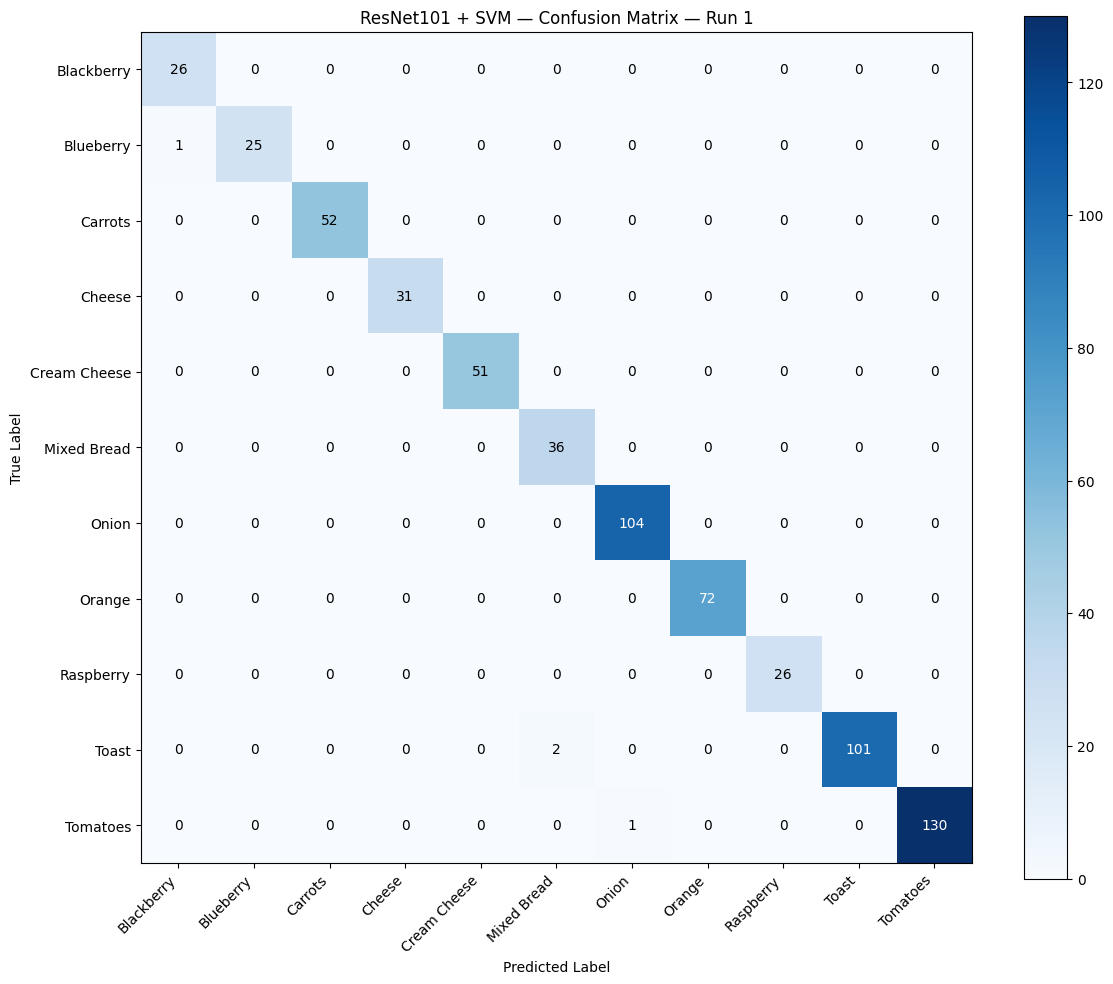

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_confusion_matrix_run1.png


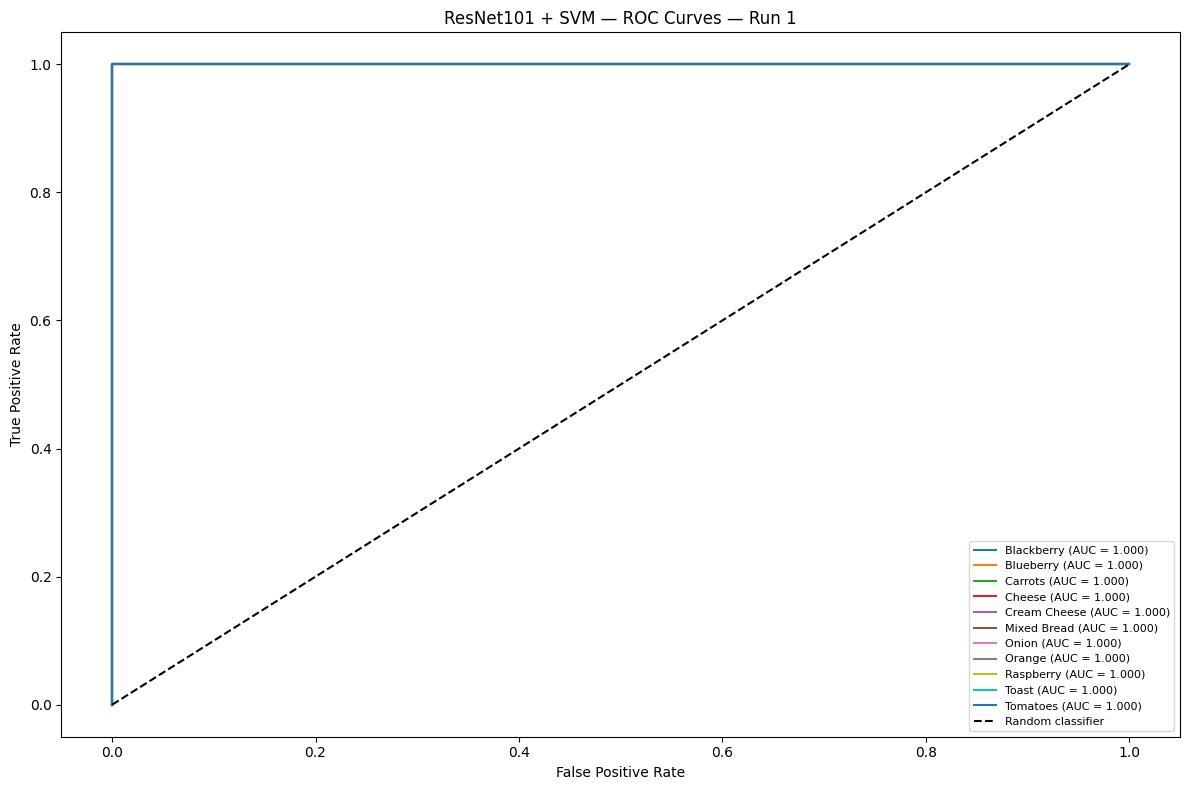

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_roc_curves_run1.png


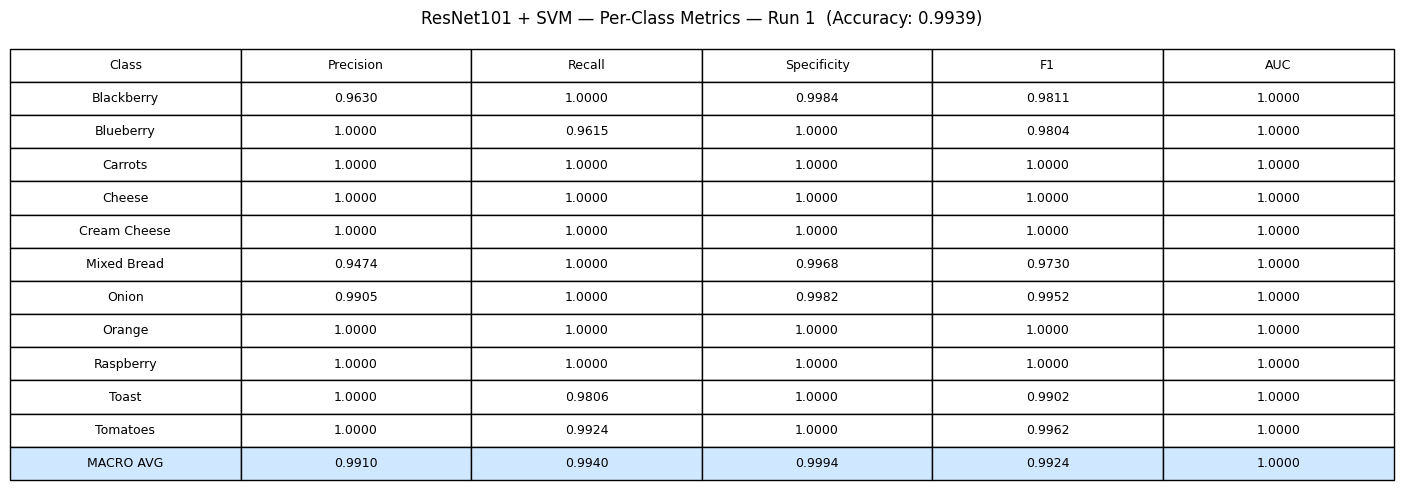

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_metrics_table_run1.png

  RUN 2 / 5  —  ResNet101 + SVM
  Seed : 42

  Training SVM on ResNet101 features...
  ✓ Training complete

  Run 2 Results
    Accuracy     : 0.9939
    Precision    : 0.9910
    Recall       : 0.9940
    Specificity  : 0.9994
    F1 Score     : 0.9924
    Mean AUC     : 1.0000


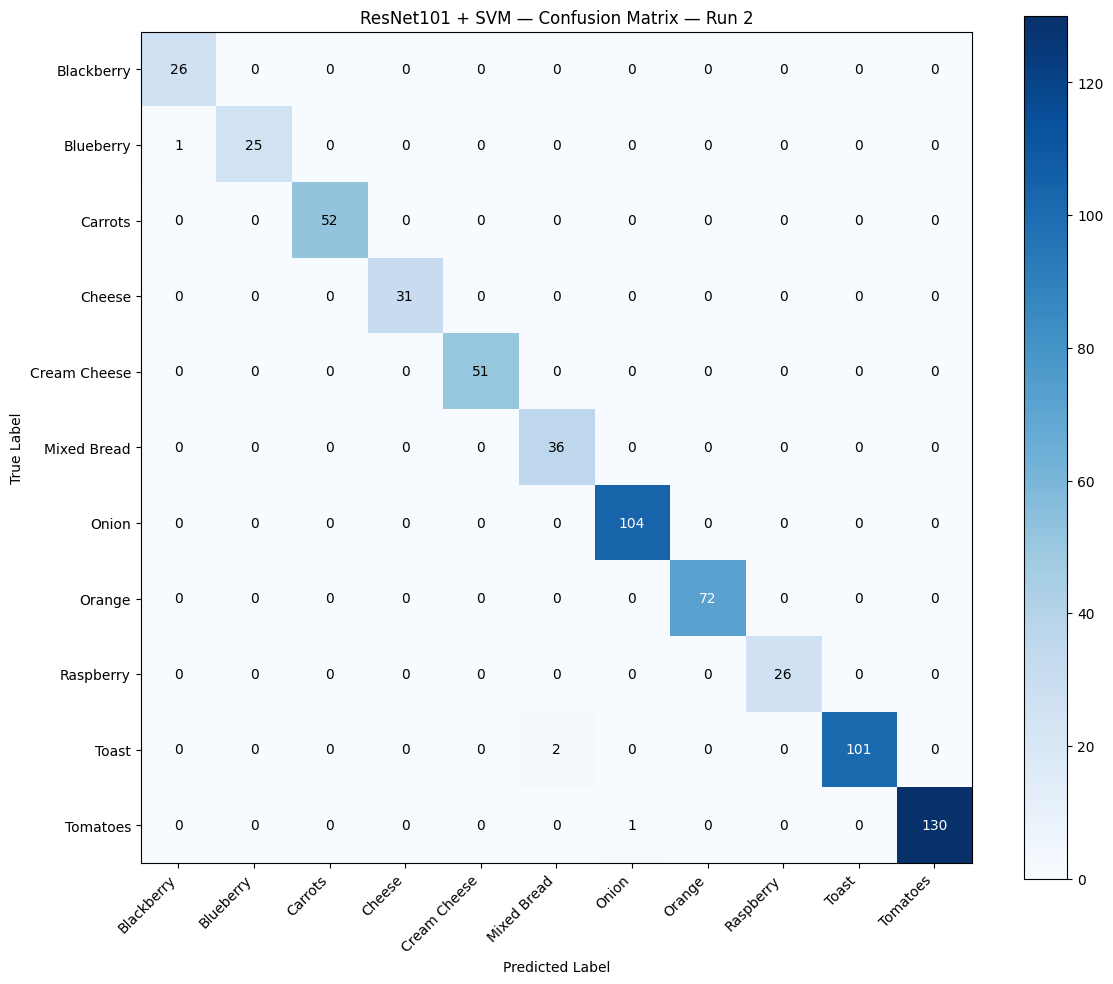

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_confusion_matrix_run2.png


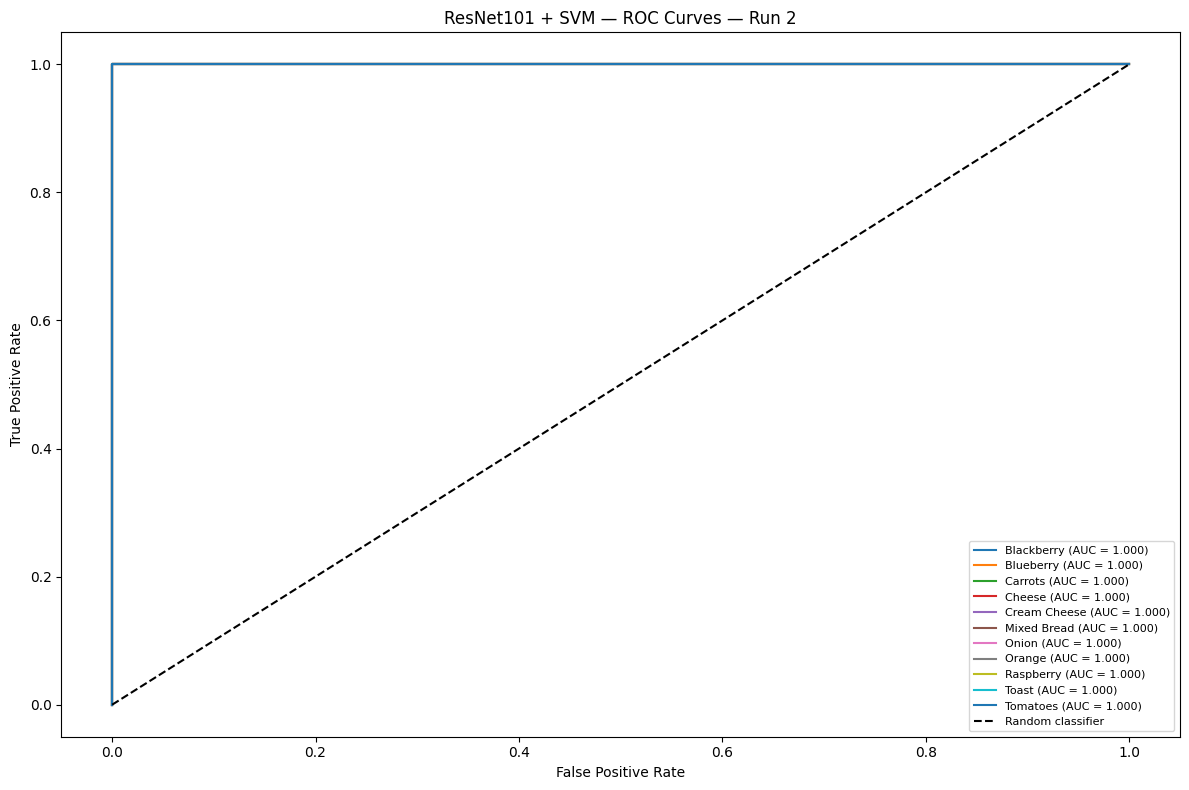

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_roc_curves_run2.png


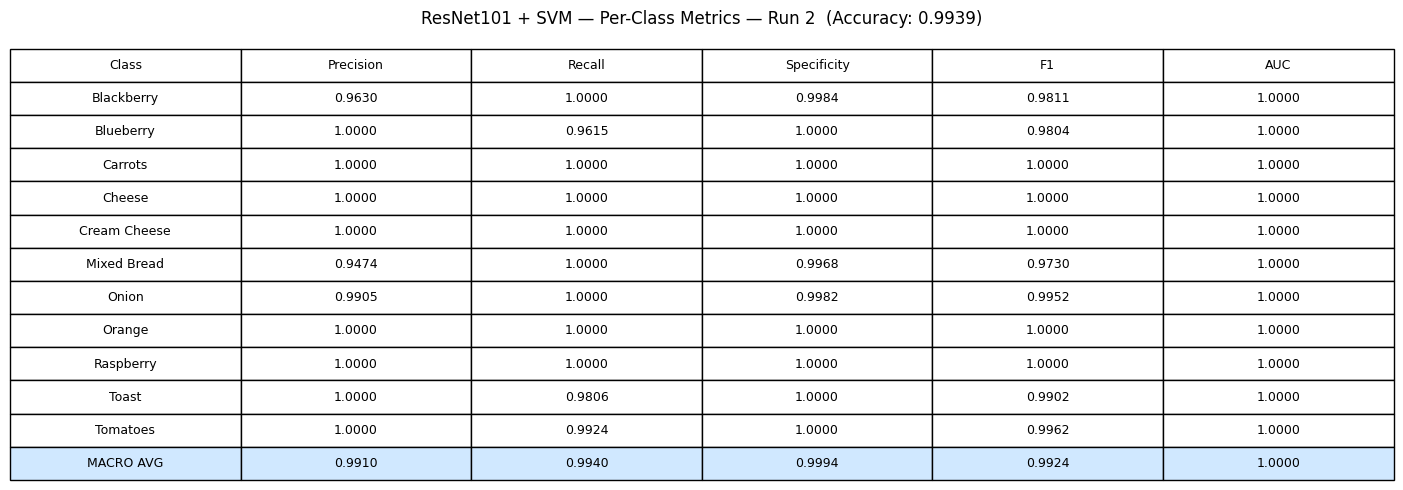

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_metrics_table_run2.png

  RUN 3 / 5  —  ResNet101 + SVM
  Seed : 99

  Training SVM on ResNet101 features...
  ✓ Training complete

  Run 3 Results
    Accuracy     : 0.9939
    Precision    : 0.9910
    Recall       : 0.9940
    Specificity  : 0.9994
    F1 Score     : 0.9924
    Mean AUC     : 1.0000


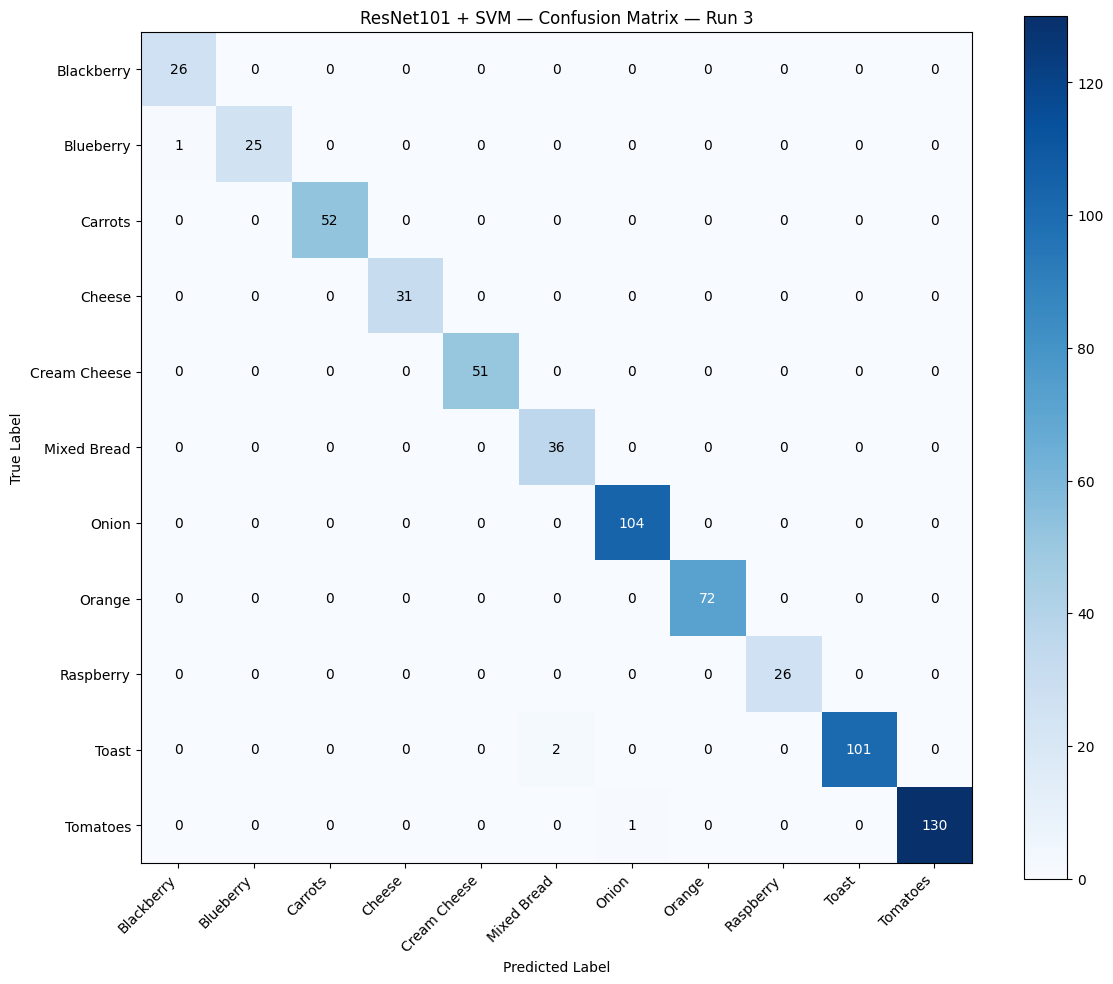

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_confusion_matrix_run3.png


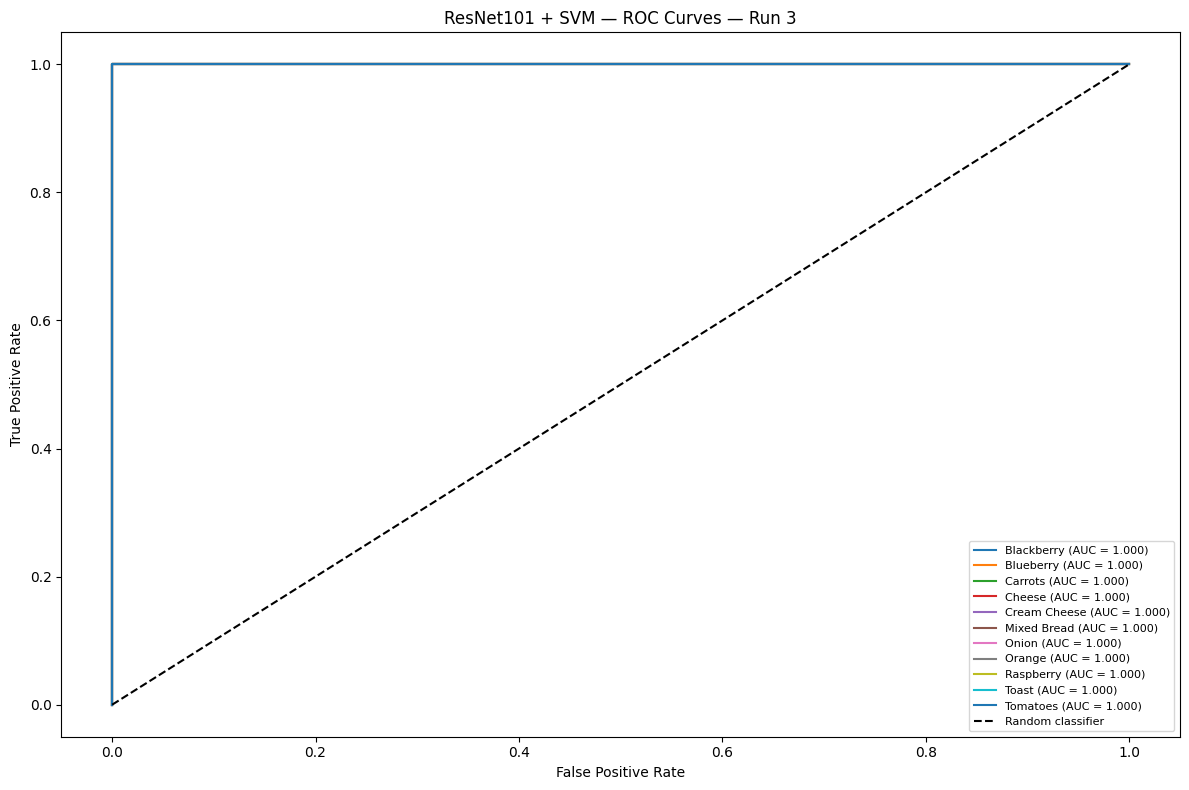

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_roc_curves_run3.png


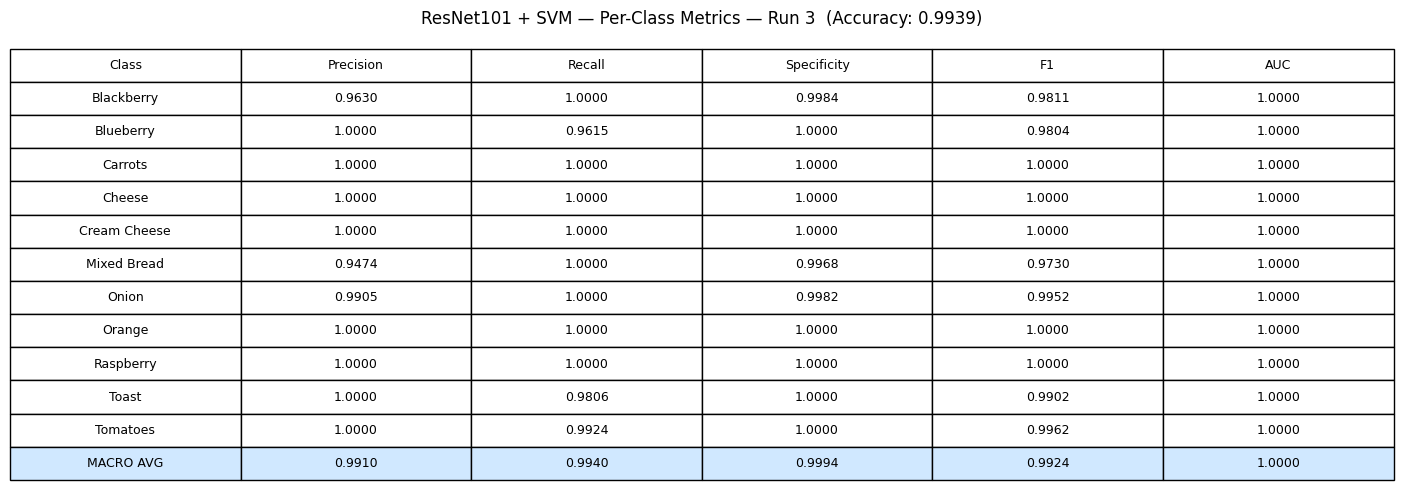

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_metrics_table_run3.png

  RUN 4 / 5  —  ResNet101 + SVM
  Seed : 123

  Training SVM on ResNet101 features...
  ✓ Training complete

  Run 4 Results
    Accuracy     : 0.9939
    Precision    : 0.9910
    Recall       : 0.9940
    Specificity  : 0.9994
    F1 Score     : 0.9924
    Mean AUC     : 1.0000


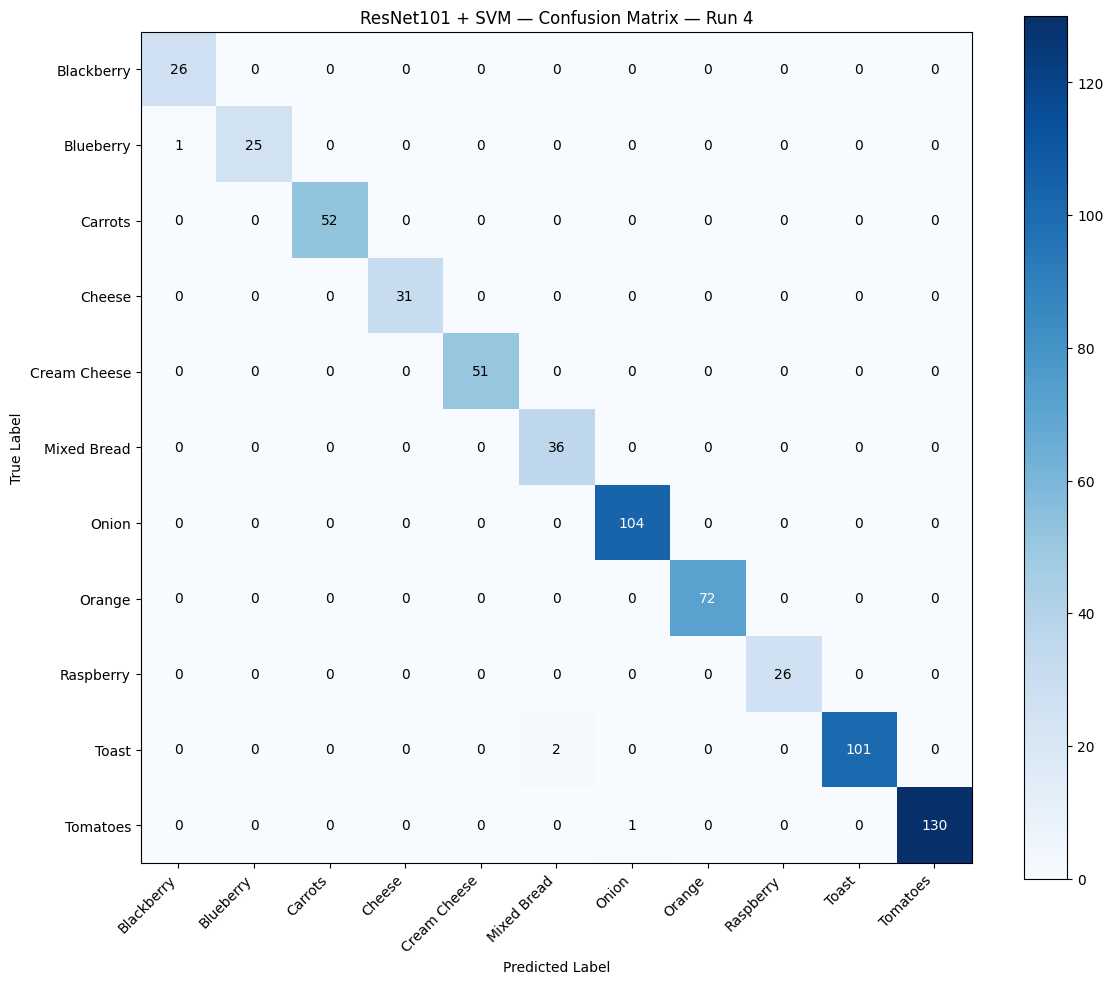

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_confusion_matrix_run4.png


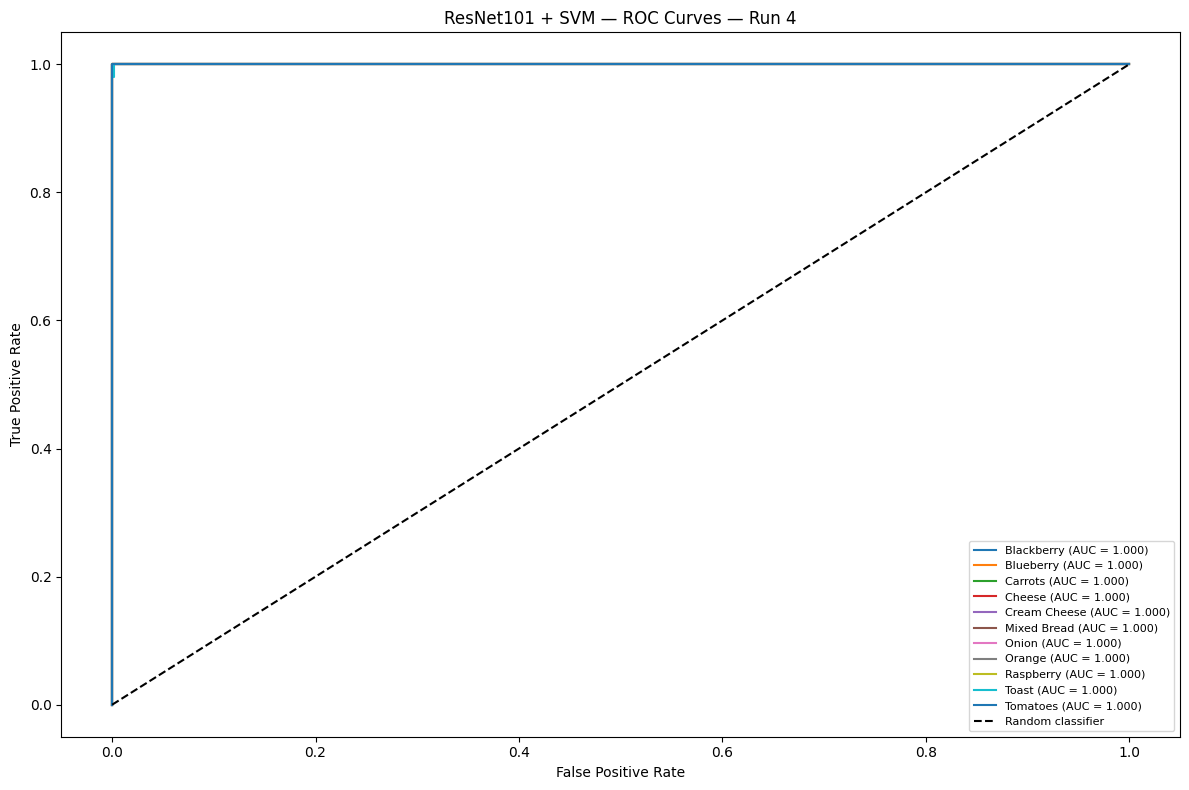

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_roc_curves_run4.png


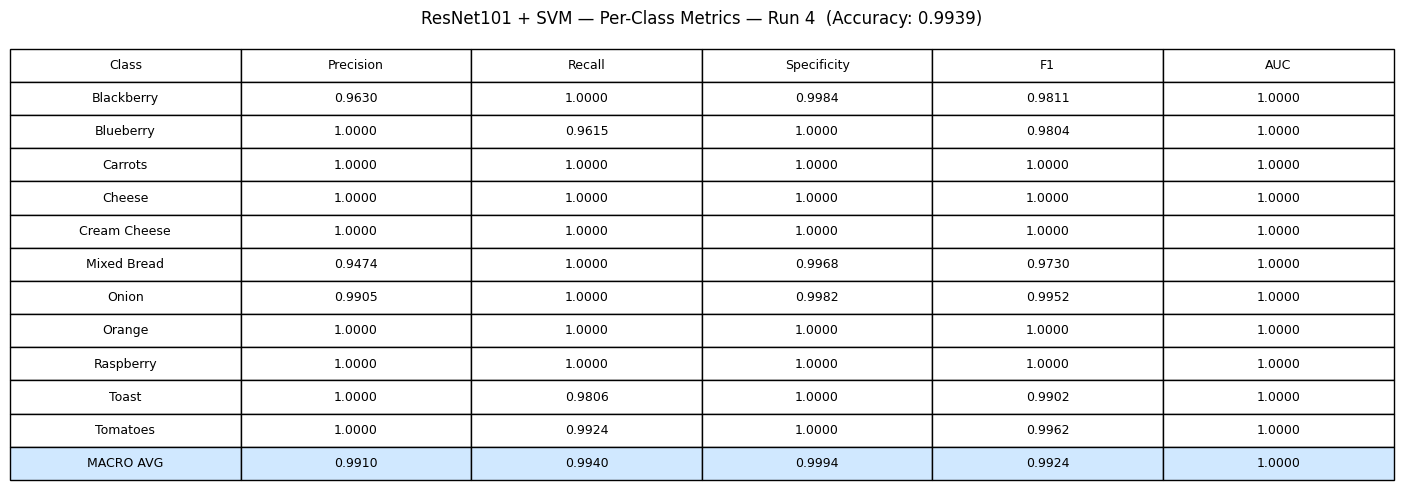

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_metrics_table_run4.png

  RUN 5 / 5  —  ResNet101 + SVM
  Seed : 256

  Training SVM on ResNet101 features...
  ✓ Training complete

  Run 5 Results
    Accuracy     : 0.9939
    Precision    : 0.9910
    Recall       : 0.9940
    Specificity  : 0.9994
    F1 Score     : 0.9924
    Mean AUC     : 1.0000


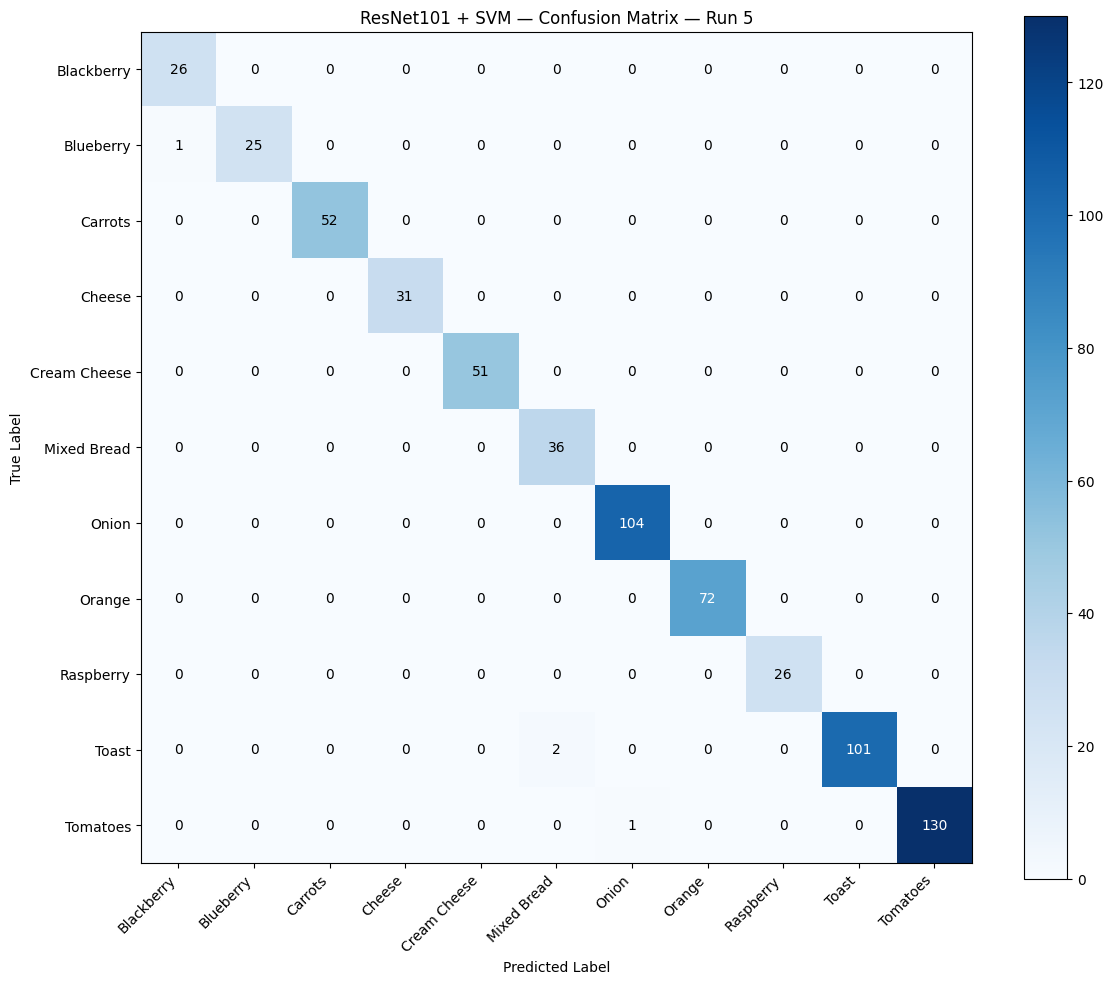

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_confusion_matrix_run5.png


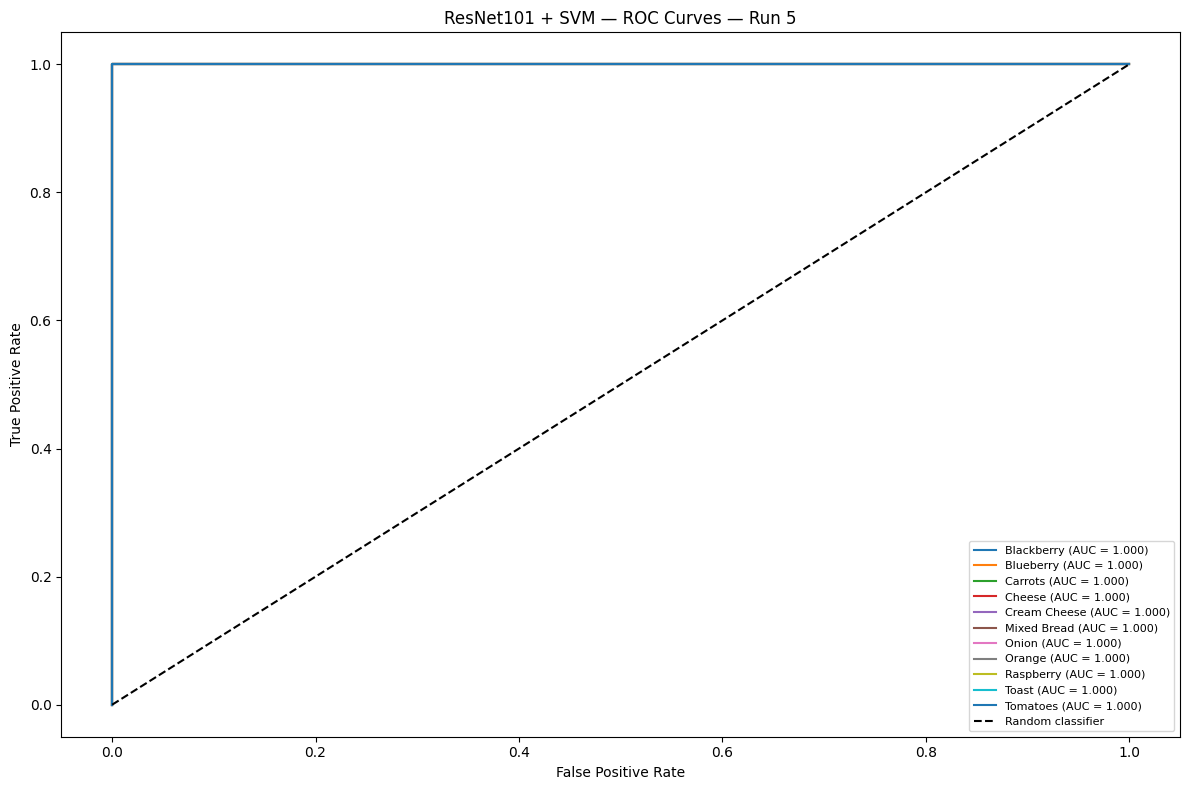

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_roc_curves_run5.png


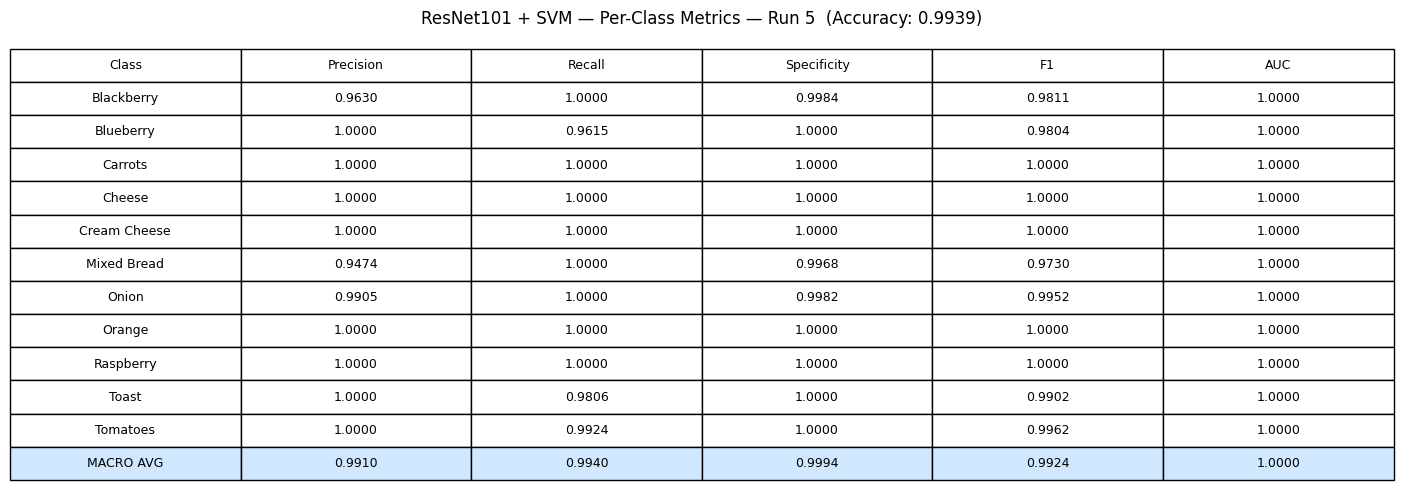

  Saved: D:\Mold Studies\Models\plots\resnet101_svm\resnet101_svm_metrics_table_run5.png

  PER-RUN RESULTS — ResNet101 + SVM
  Run       Seed    Test Acc   Precision Sensitivity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────
  1           27      0.9939      0.9910      0.9940    0.9924    1.0000
  2           42      0.9939      0.9910      0.9940    0.9924    1.0000
  3           99      0.9939      0.9910      0.9940    0.9924    1.0000
  4          123      0.9939      0.9910      0.9940    0.9924    1.0000
  5          256      0.9939      0.9910      0.9940    0.9924    1.0000
──────────────────────────────────────────────────────────────────────────────

──────────────────────────────  Statistical Summary  ──────────────────────────────
  Metric              Mean       Std       Min       Max              95% CI
──────────────────────────────────────────────────────────────────────────────
  Accuracy          0.9939    0.0000 

c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [3]:
"""
Fragment 3 — SVM Classification on ResNet101 Features (5 Runs)
===============================================================
ResNet101 Hybrid Pipeline — Feature Extraction + SVM Classification

- Loads ResNet101 extracted features from disk
- Trains SVM 5 times using different random seeds
- Each run shuffles train features differently
- Evaluates on test features — never seen during training
- Computes full metrics + 95% confidence intervals
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "resnet101_svm")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]

os.makedirs(PLOT_DIR, exist_ok=True)

# ── SVM Parameters ────────────────────────────────────────────────────────────

SVM_KERNEL = "linear"
SVM_C      = 1.0
SVM_GAMMA  = "scale"

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob):
    cm        = confusion_matrix(y_true, y_pred)
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    specificities = []
    for i in range(NUM_CLASSES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    specificity = np.mean(specificities)

    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc    = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr)
        }

    return {
        "cm"         : cm,
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "roc_auc"    : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"ResNet101 + SVM — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"resnet101_svm_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cls in CLASS_NAMES:
        ax.plot(
            roc_auc[cls]["fpr"],
            roc_auc[cls]["tpr"],
            label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"ResNet101 + SVM — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"resnet101_svm_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    rows = []
    for i, cls in enumerate(CLASS_NAMES):
        cm   = metrics["cm"]
        tp   = cm[i, i]
        fp   = cm[:, i].sum() - tp
        fn   = cm[i, :].sum() - tp
        tn   = cm.sum() - tp - fp - fn
        prec = tp / (tp + fp + 1e-7)
        rec  = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        f1   = 2 * prec * rec / (prec + rec + 1e-7)
        rows.append([
            cls,
            f"{prec:.4f}",
            f"{rec:.4f}",
            f"{spec:.4f}",
            f"{f1:.4f}",
            f"{metrics['roc_auc'][cls]['auc']:.4f}",
        ])

    rows.append([
        "MACRO AVG",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}",
    ])

    col_labels = ["Class", "Precision", "Recall",
                  "Specificity", "F1", "AUC"]

    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        table[len(rows), j].set_facecolor("#d0e8ff")

    ax.set_title(
        f"ResNet101 + SVM — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"resnet101_svm_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 3 — ResNet101 + SVM  (5 Runs)")
print("=" * 60)
print(f"  Feature source : ResNet101 extracted (2048 features)")
print(f"  Kernel         : {SVM_KERNEL}")
print(f"  C              : {SVM_C}")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  ResNet101 + SVM")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    # ── Shuffle train features with this run's seed ───────────────────────────
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train))
    X_tr    = X_train[indices]
    y_tr    = y_train[indices]

    # ── Scale features ────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test)

    # ── Train SVM ─────────────────────────────────────────────────────────────
    print(f"  Training SVM on ResNet101 features...")
    svm = SVC(
        kernel       = SVM_KERNEL,
        C            = SVM_C,
        gamma        = SVM_GAMMA,
        probability  = True,
        random_state = seed,
    )
    svm.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate on test features ─────────────────────────────────────────────
    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)

    metrics         = compute_metrics(y_test, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "mean_auc"   : np.mean([metrics["roc_auc"][c]["auc"]
                                 for c in CLASS_NAMES]),
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Recall       : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    Mean AUC     : "
          f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

    plot_confusion_matrix(metrics["cm"],    run_idx, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],     run_idx, PLOT_DIR)
    plot_metrics_table(metrics,             run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_seed = 8
col_test = 12
col_prec = 12
col_sens = 12
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_seed + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — ResNet101 + SVM")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Test Acc':>{col_test}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_test}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['mean_auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*30}  Statistical Summary  {'─'*30}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["mean_auc"]    for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: Expose for comparison ─────────────────────────────────────────────

resnet101_svm_all_metrics     = all_metrics
resnet101_svm_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 3 complete.")
print(f"     resnet101_svm_all_metrics and "
      f"resnet101_svm_all_run_results ready.")
print(f"     Proceed to Fragment 4 — KNN on ResNet101 features.\n")

  Fragment 4 — ResNet101 + KNN  (5 Runs)
  Feature source : ResNet101 extracted (2048 features)
  N Neighbours   : 5
  Metric         : euclidean
  Weights        : distance
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  ResNet101 + KNN
  Seed : 27

  Training KNN on ResNet101 features...
  ✓ Training complete
  Predicting...

  Run 1 Results
    Accuracy     : 0.9924
    Precision    : 0.9901
    Recall       : 0.9932
    Specificity  : 0.9992
    F1 Score     : 0.9915
    Mean AUC     : 1.0000


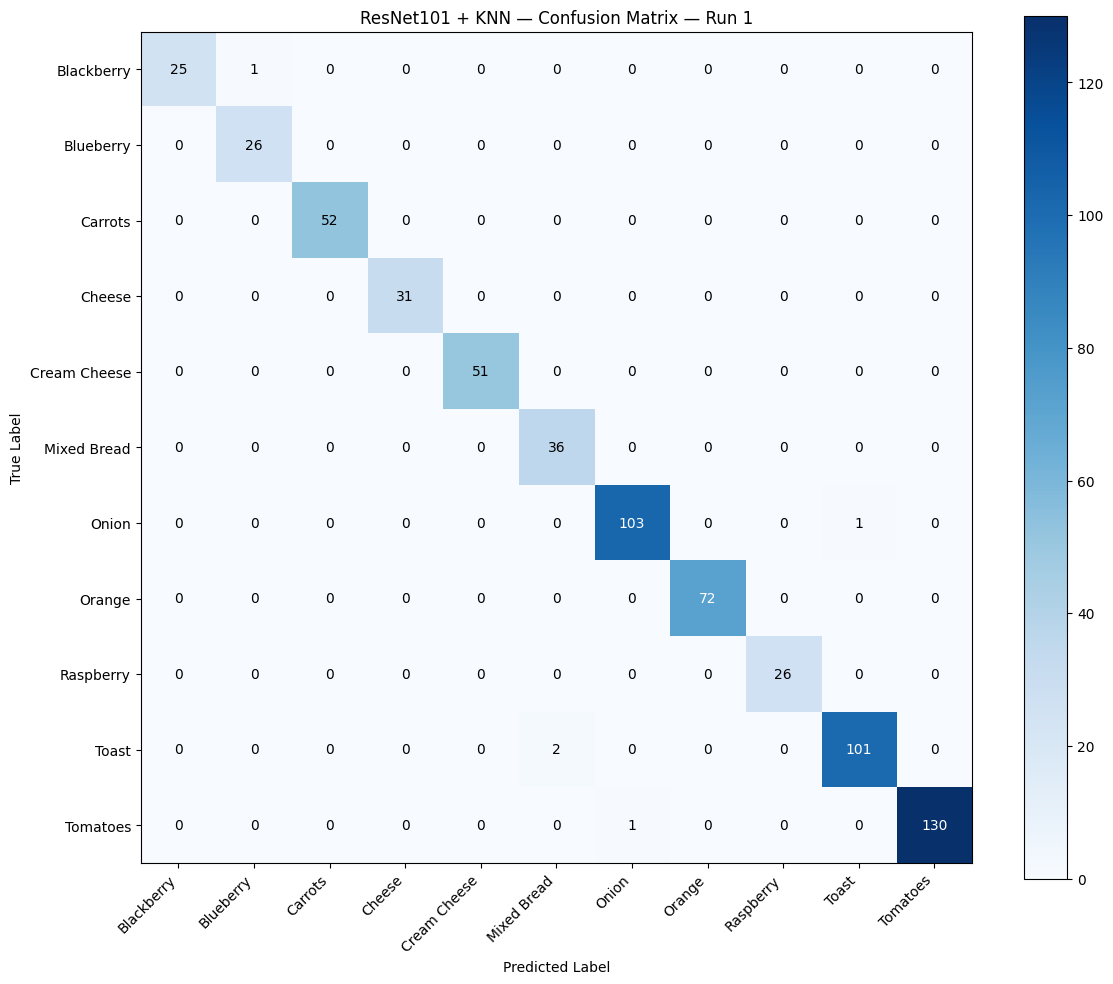

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_confusion_matrix_run1.png


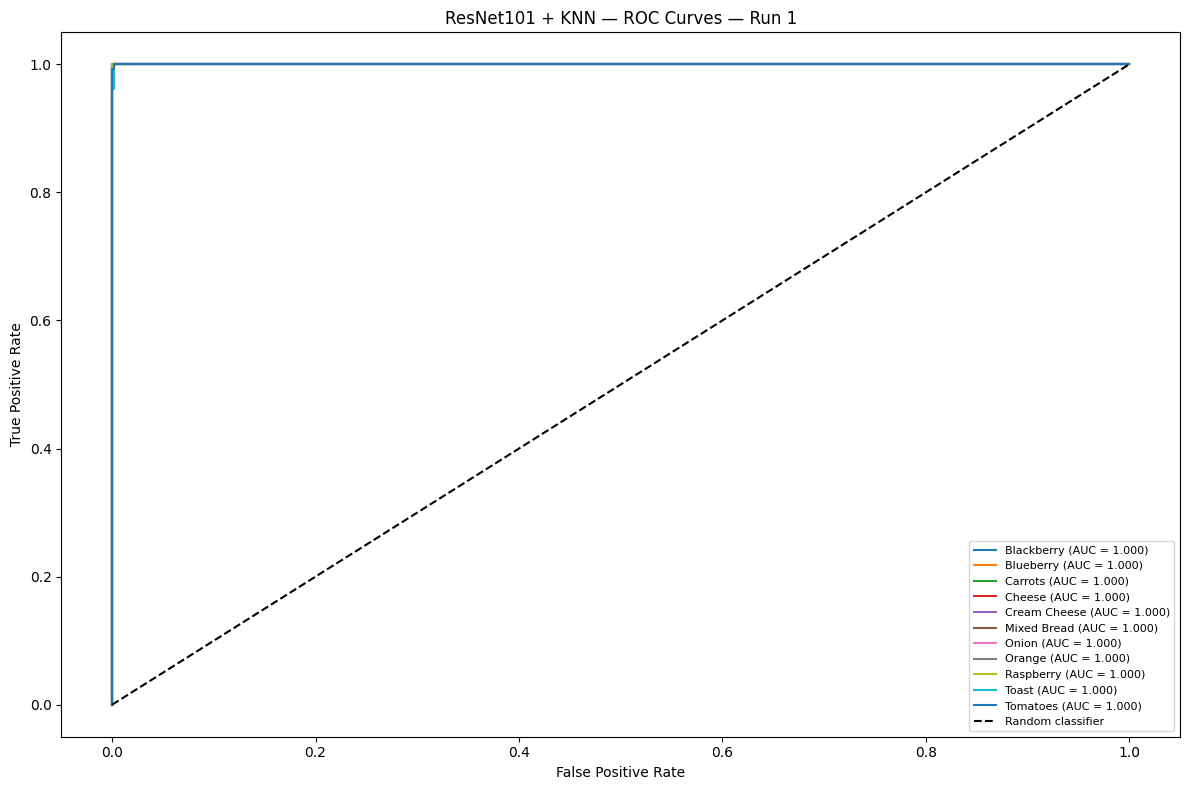

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_roc_curves_run1.png


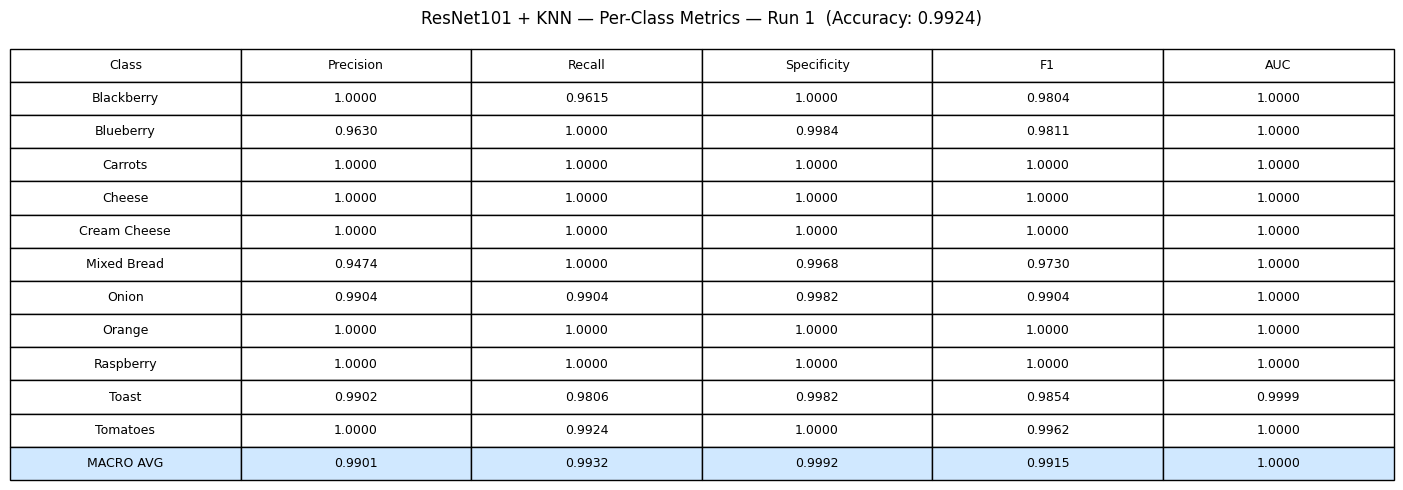

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_metrics_table_run1.png

  RUN 2 / 5  —  ResNet101 + KNN
  Seed : 42

  Training KNN on ResNet101 features...
  ✓ Training complete
  Predicting...

  Run 2 Results
    Accuracy     : 0.9924
    Precision    : 0.9901
    Recall       : 0.9932
    Specificity  : 0.9992
    F1 Score     : 0.9915
    Mean AUC     : 1.0000


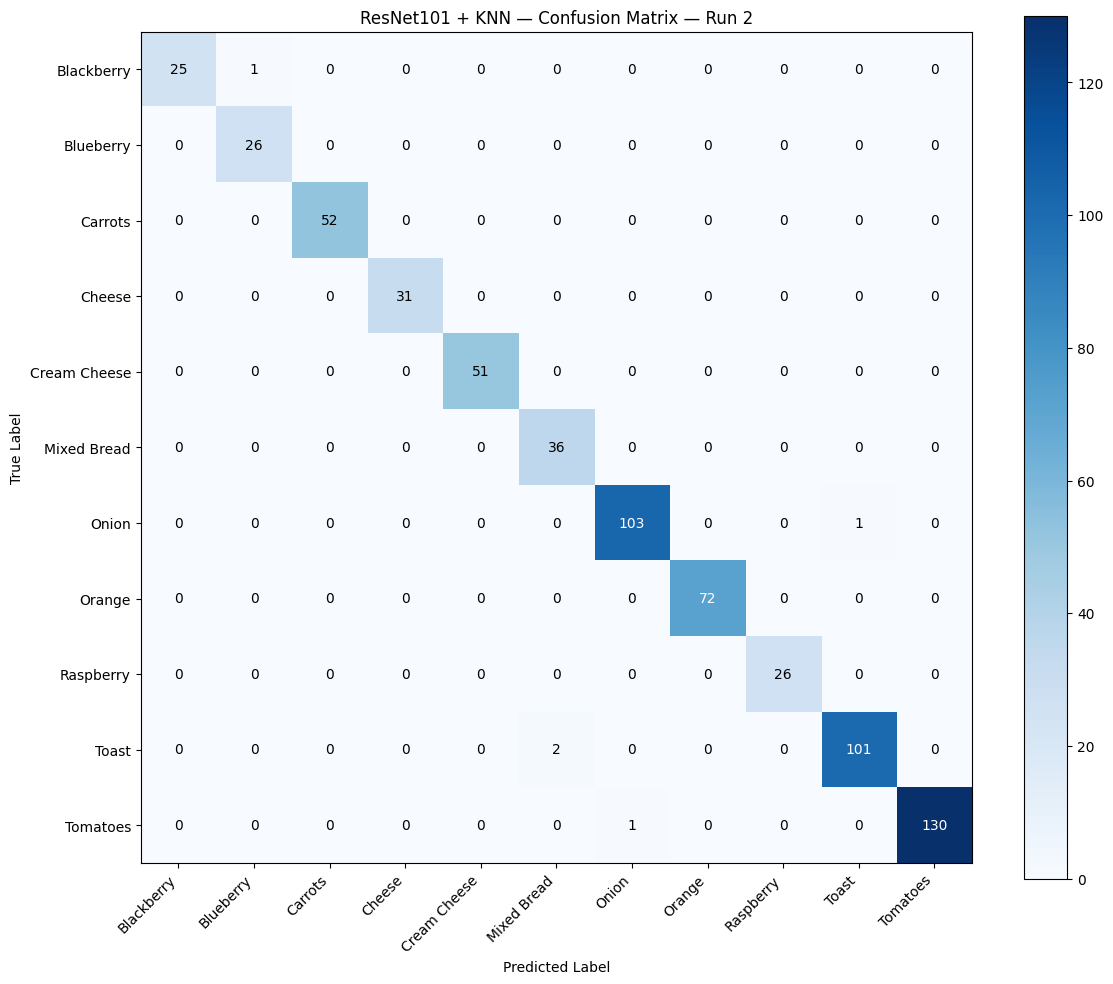

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_confusion_matrix_run2.png


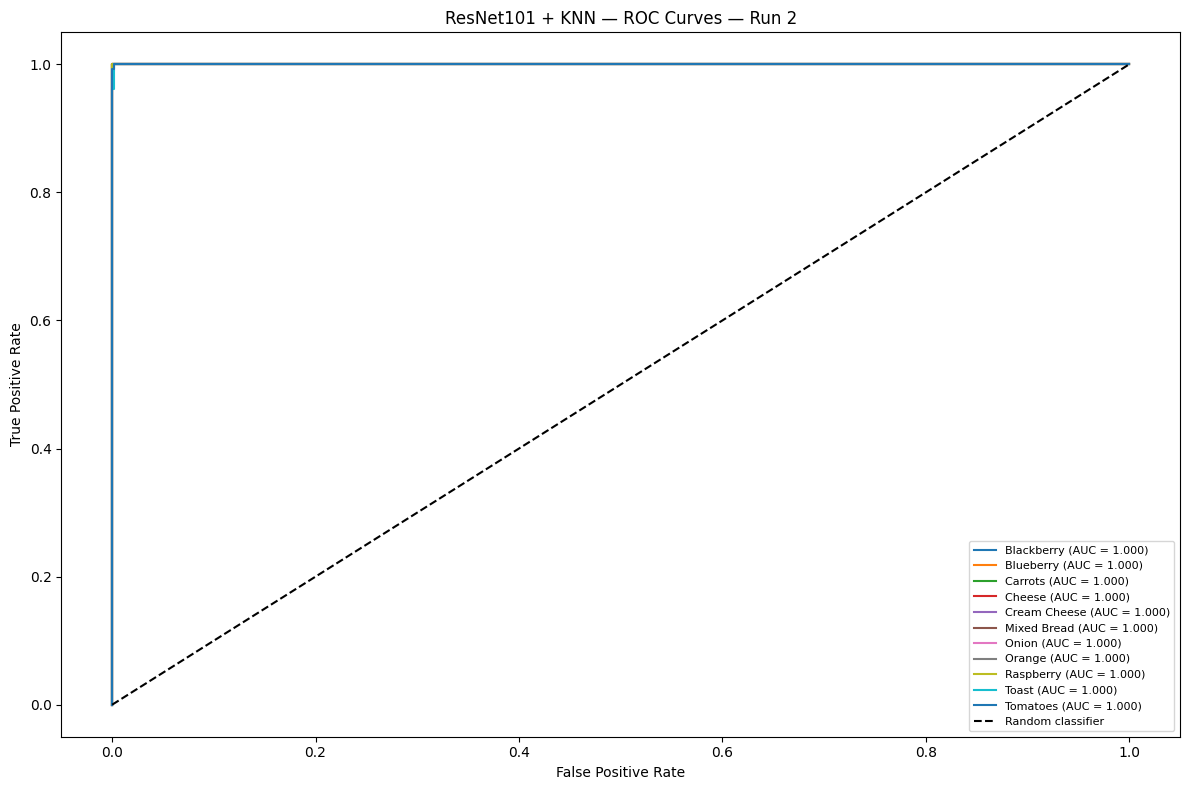

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_roc_curves_run2.png


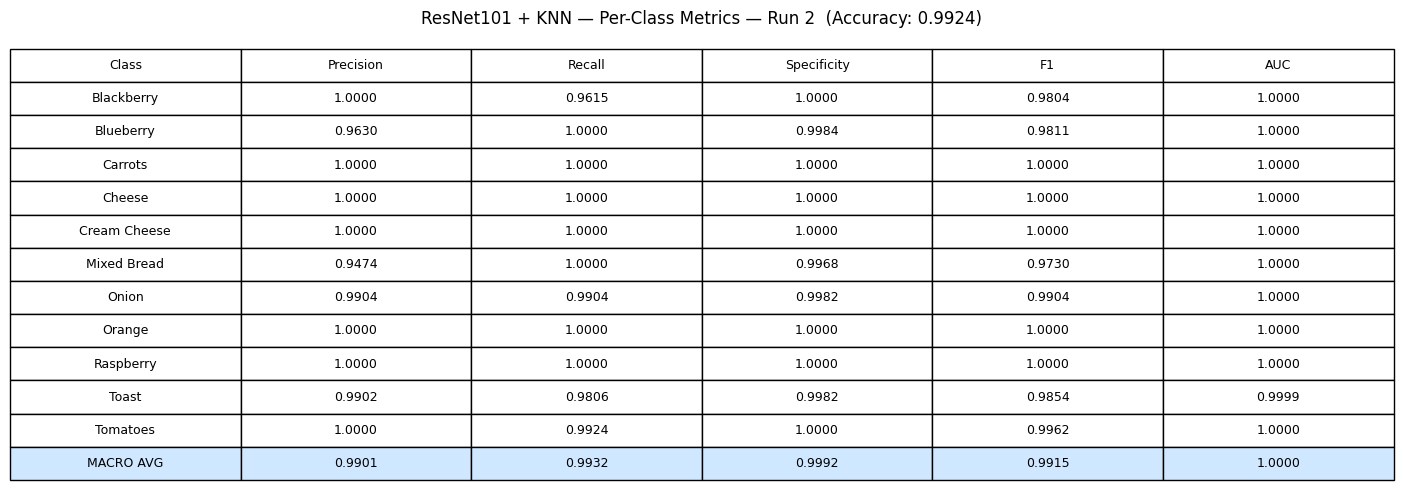

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_metrics_table_run2.png

  RUN 3 / 5  —  ResNet101 + KNN
  Seed : 99

  Training KNN on ResNet101 features...
  ✓ Training complete
  Predicting...

  Run 3 Results
    Accuracy     : 0.9924
    Precision    : 0.9901
    Recall       : 0.9932
    Specificity  : 0.9992
    F1 Score     : 0.9915
    Mean AUC     : 1.0000


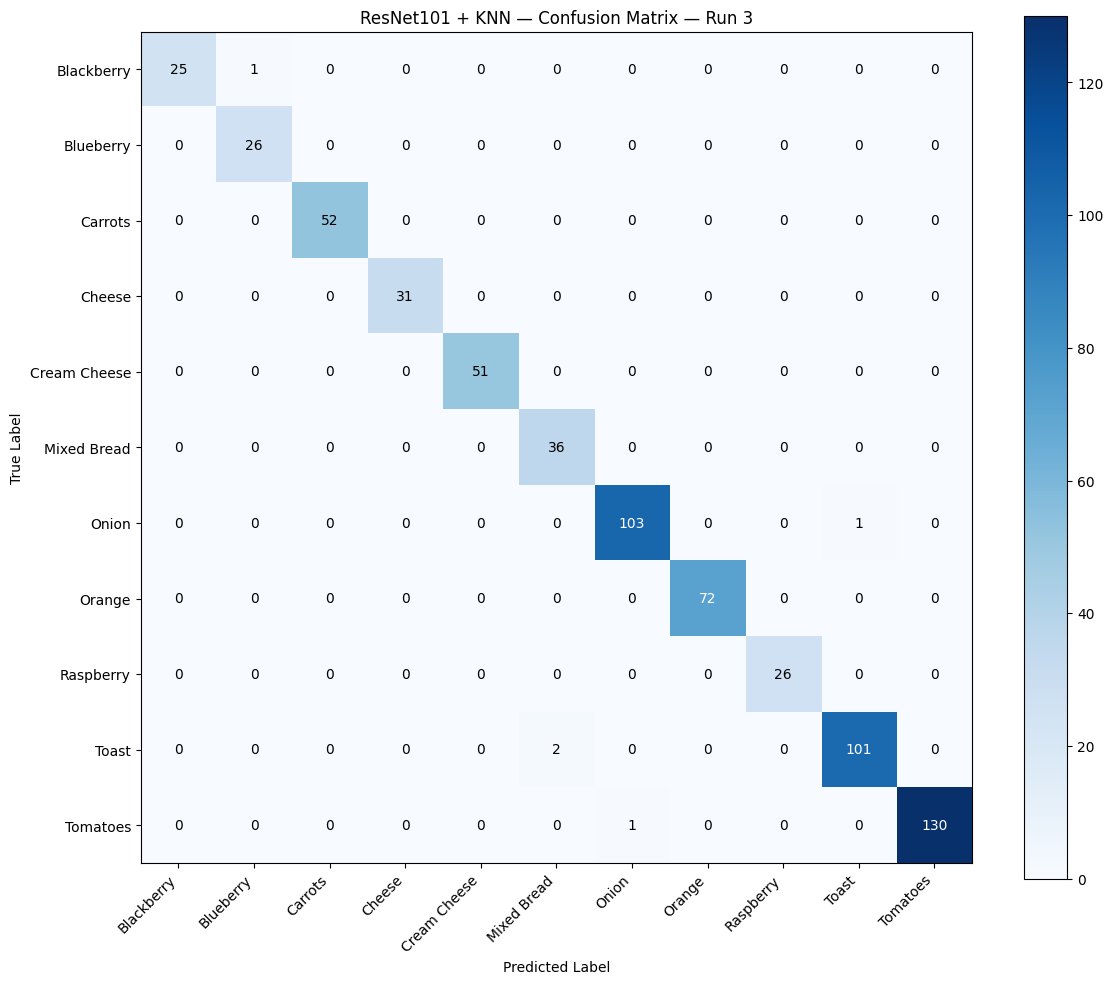

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_confusion_matrix_run3.png


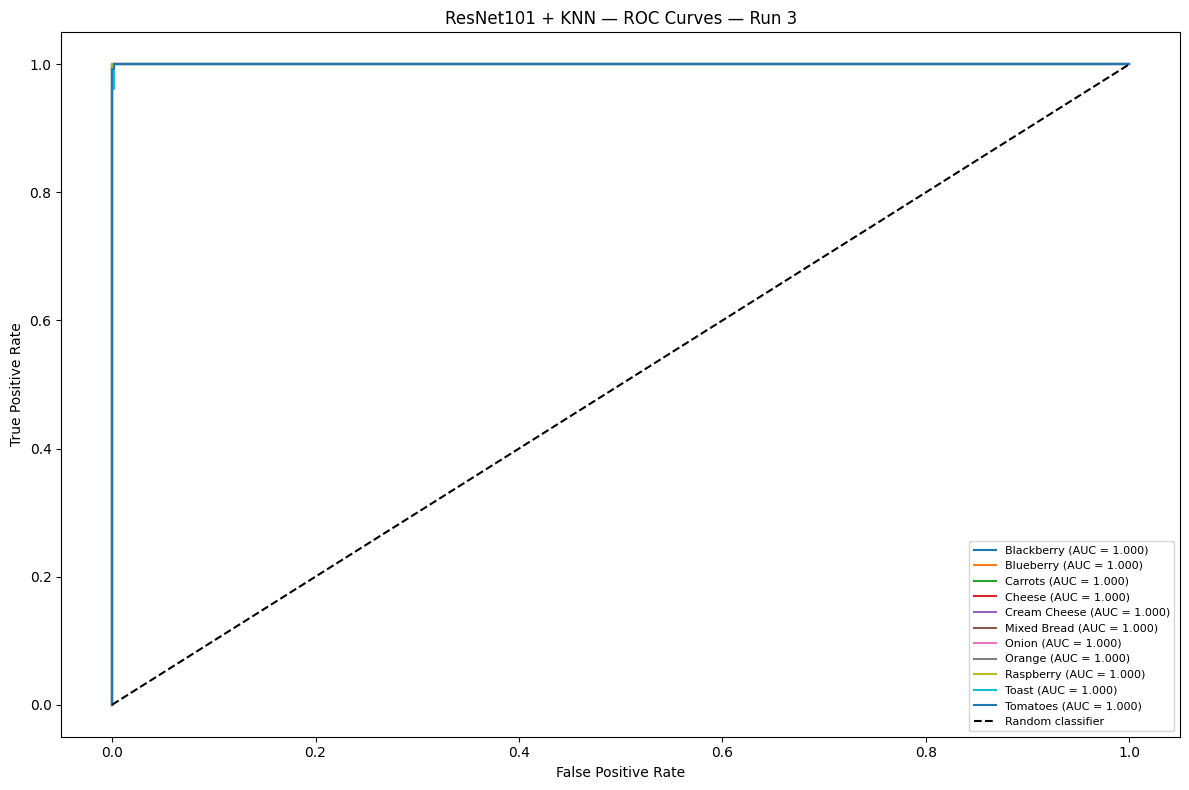

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_roc_curves_run3.png


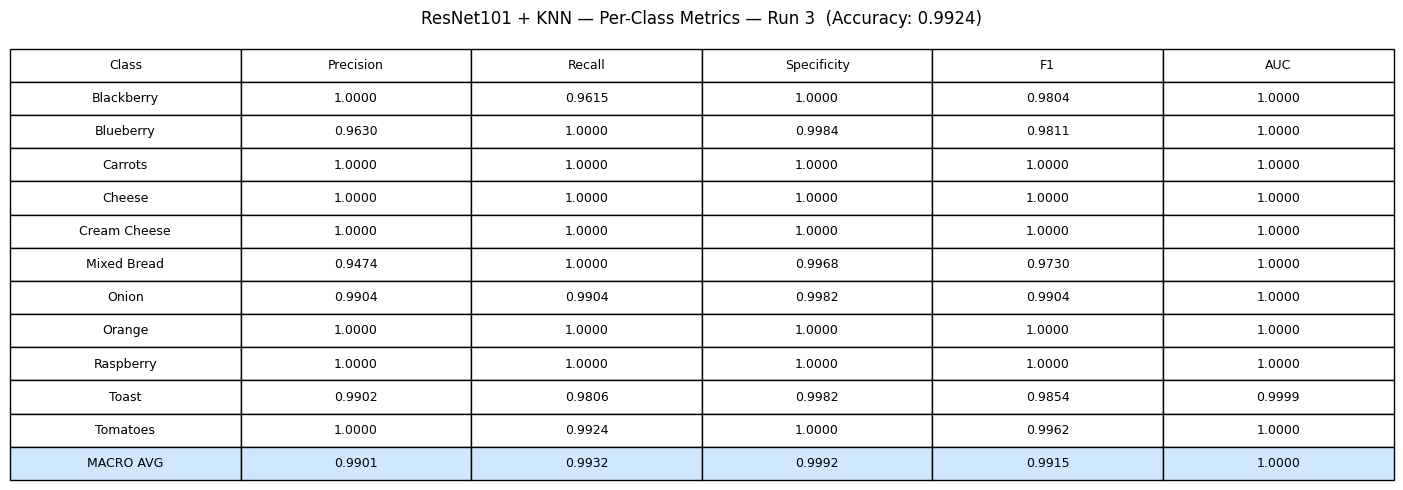

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_metrics_table_run3.png

  RUN 4 / 5  —  ResNet101 + KNN
  Seed : 123

  Training KNN on ResNet101 features...
  ✓ Training complete
  Predicting...

  Run 4 Results
    Accuracy     : 0.9924
    Precision    : 0.9901
    Recall       : 0.9932
    Specificity  : 0.9992
    F1 Score     : 0.9915
    Mean AUC     : 1.0000


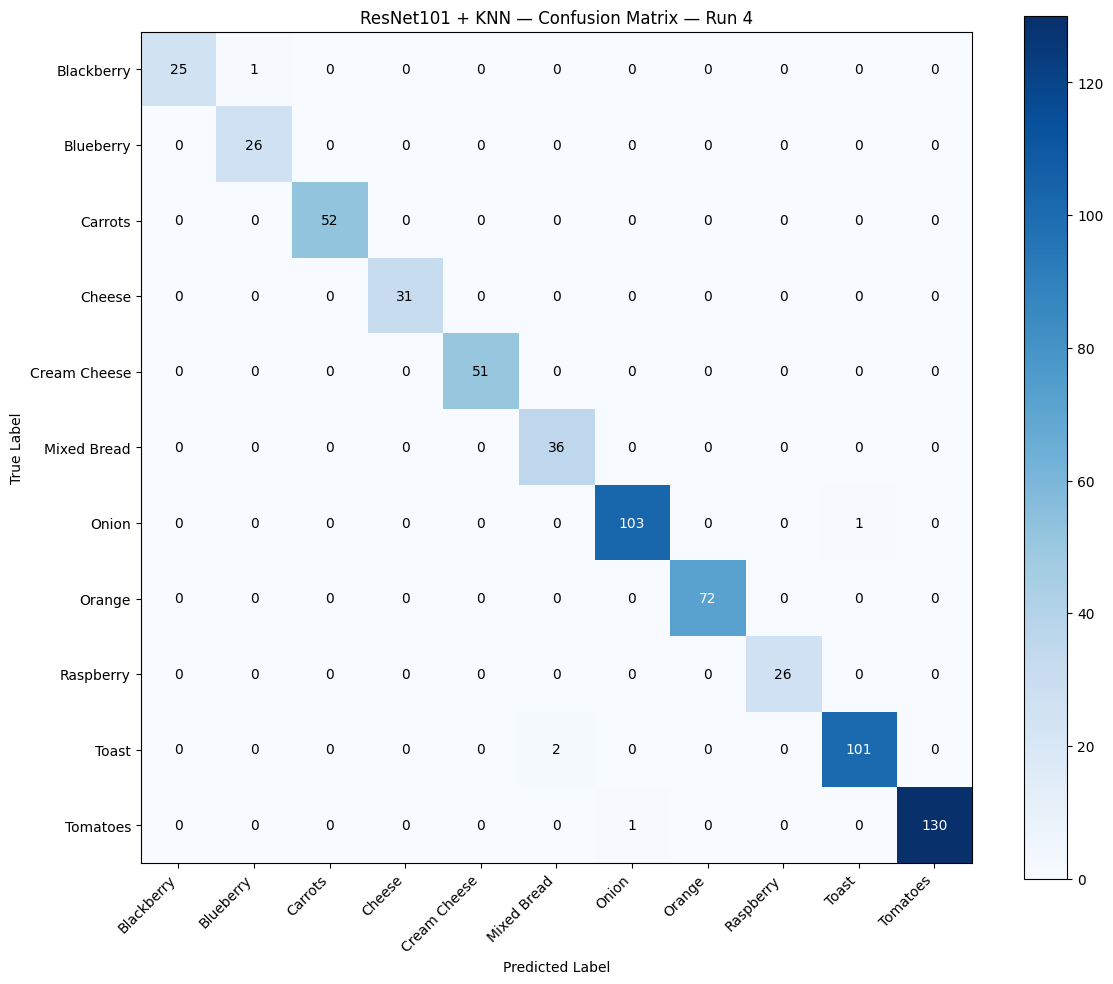

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_confusion_matrix_run4.png


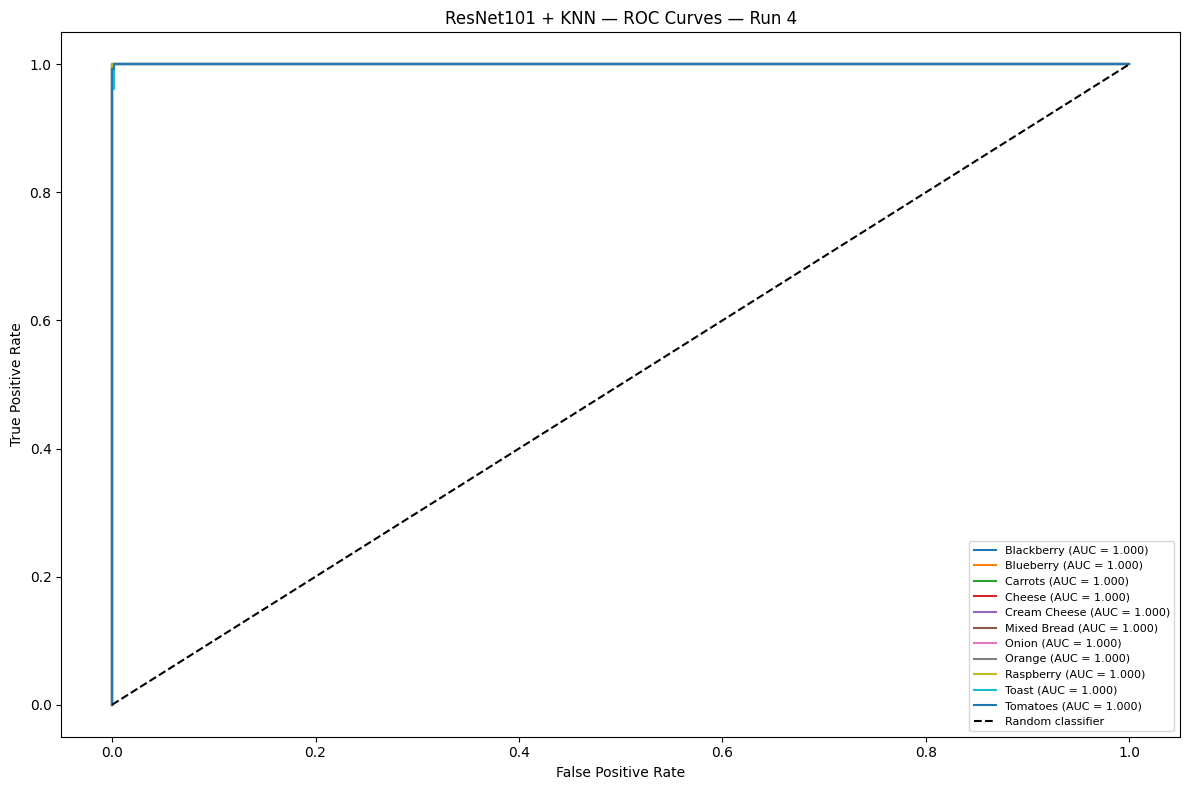

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_roc_curves_run4.png


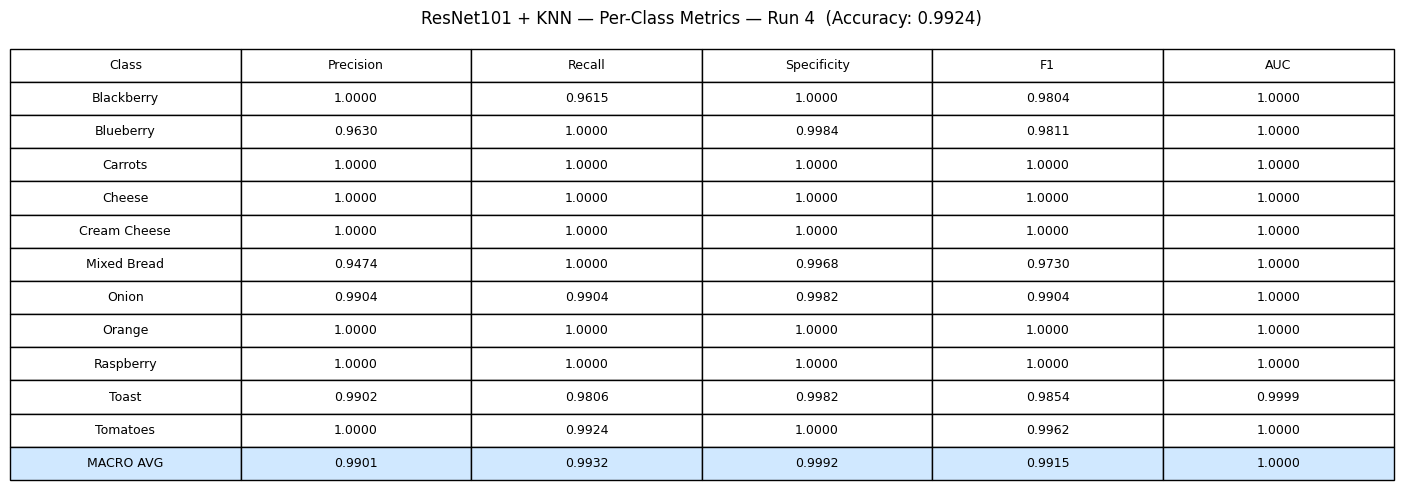

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_metrics_table_run4.png

  RUN 5 / 5  —  ResNet101 + KNN
  Seed : 256

  Training KNN on ResNet101 features...
  ✓ Training complete
  Predicting...

  Run 5 Results
    Accuracy     : 0.9924
    Precision    : 0.9901
    Recall       : 0.9932
    Specificity  : 0.9992
    F1 Score     : 0.9915
    Mean AUC     : 1.0000


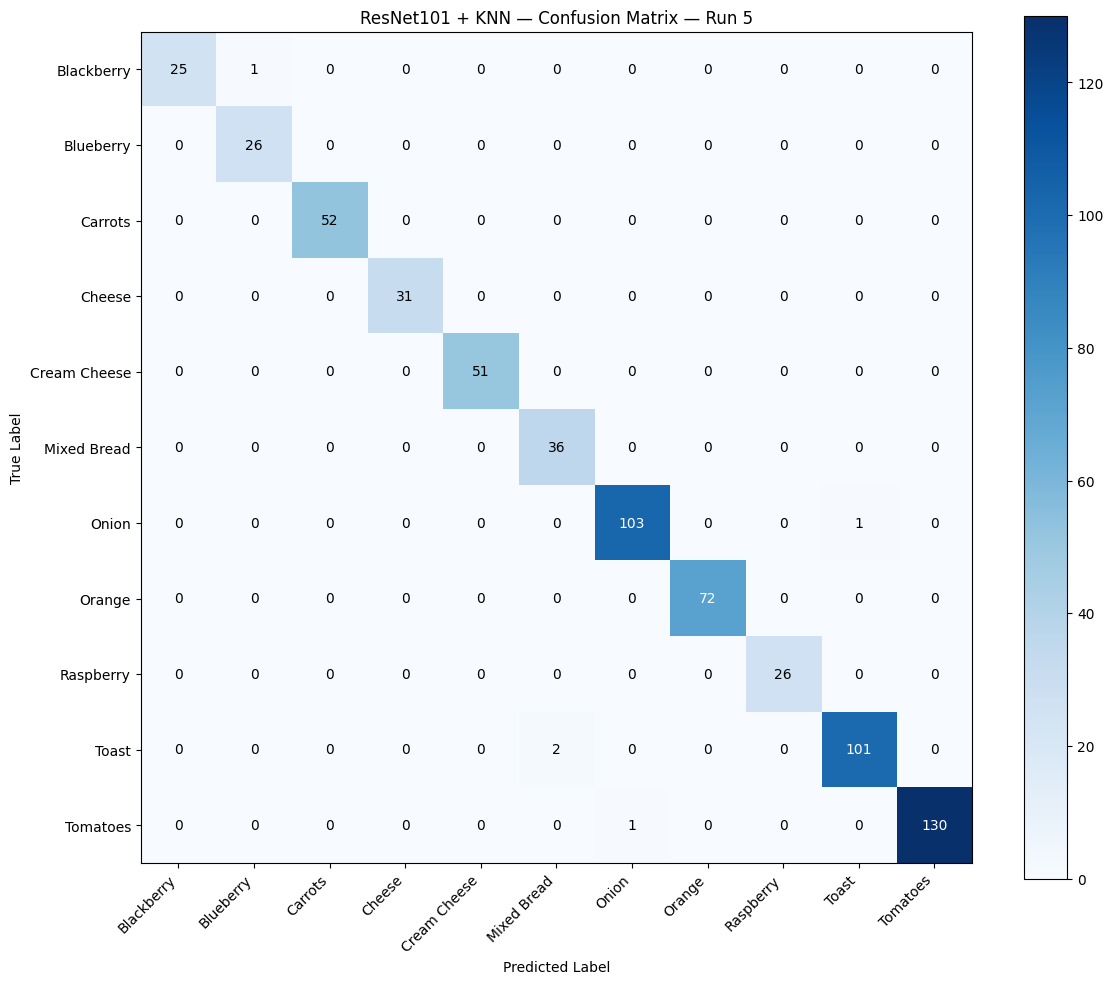

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_confusion_matrix_run5.png


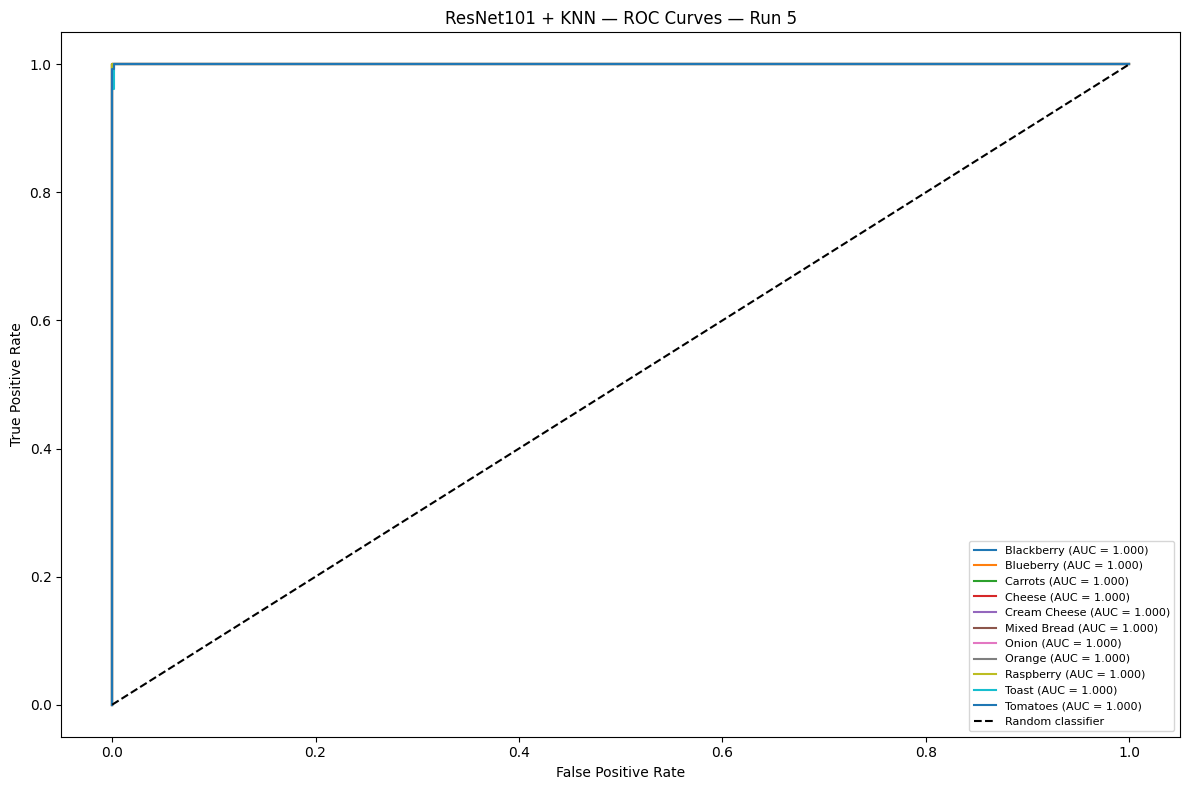

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_roc_curves_run5.png


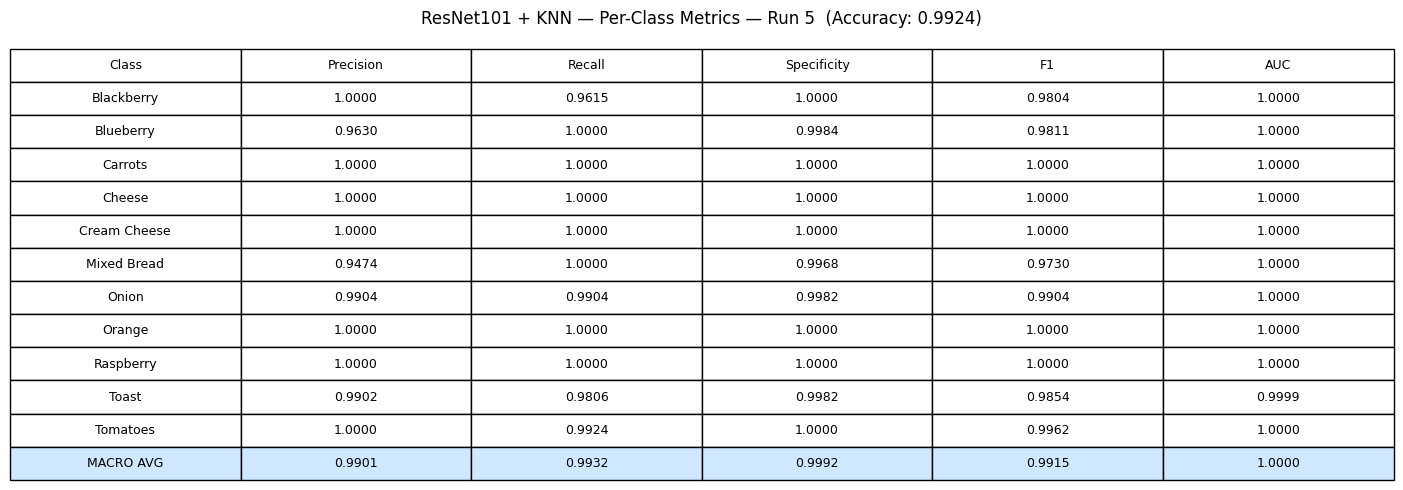

  Saved: D:\Mold Studies\Models\plots\resnet101_knn\resnet101_knn_metrics_table_run5.png

  PER-RUN RESULTS — ResNet101 + KNN
  Run       Seed    Test Acc   Precision Sensitivity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────
  1           27      0.9924      0.9901      0.9932    0.9915    1.0000
  2           42      0.9924      0.9901      0.9932    0.9915    1.0000
  3           99      0.9924      0.9901      0.9932    0.9915    1.0000
  4          123      0.9924      0.9901      0.9932    0.9915    1.0000
  5          256      0.9924      0.9901      0.9932    0.9915    1.0000
──────────────────────────────────────────────────────────────────────────────

──────────────────────────────  Statistical Summary  ──────────────────────────────
  Metric              Mean       Std       Min       Max              95% CI
──────────────────────────────────────────────────────────────────────────────
  Accuracy          0.9924    0.0000 

c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [4]:
"""
Fragment 4 — KNN Classification on ResNet101 Features (5 Runs)
===============================================================
ResNet101 Hybrid Pipeline — Feature Extraction + KNN Classification

- Reuses ResNet101 extracted features already on disk
- Trains KNN 5 times using different random seeds
- Each run shuffles train features differently
- Evaluates on test features — never seen during training
- Computes full metrics + 95% confidence intervals
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "resnet101_knn")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]

os.makedirs(PLOT_DIR, exist_ok=True)

# ── KNN Parameters ────────────────────────────────────────────────────────────

KNN_N_NEIGHBORS = 5
KNN_METRIC      = "euclidean"
KNN_WEIGHTS     = "distance"

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob):
    cm        = confusion_matrix(y_true, y_pred)
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    specificities = []
    for i in range(NUM_CLASSES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    specificity = np.mean(specificities)

    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc    = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr)
        }

    return {
        "cm"         : cm,
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "roc_auc"    : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"ResNet101 + KNN — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"resnet101_knn_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cls in CLASS_NAMES:
        ax.plot(
            roc_auc[cls]["fpr"],
            roc_auc[cls]["tpr"],
            label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"ResNet101 + KNN — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"resnet101_knn_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    rows = []
    for i, cls in enumerate(CLASS_NAMES):
        cm   = metrics["cm"]
        tp   = cm[i, i]
        fp   = cm[:, i].sum() - tp
        fn   = cm[i, :].sum() - tp
        tn   = cm.sum() - tp - fp - fn
        prec = tp / (tp + fp + 1e-7)
        rec  = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        f1   = 2 * prec * rec / (prec + rec + 1e-7)
        rows.append([
            cls,
            f"{prec:.4f}",
            f"{rec:.4f}",
            f"{spec:.4f}",
            f"{f1:.4f}",
            f"{metrics['roc_auc'][cls]['auc']:.4f}",
        ])

    rows.append([
        "MACRO AVG",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}",
    ])

    col_labels = ["Class", "Precision", "Recall",
                  "Specificity", "F1", "AUC"]

    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        table[len(rows), j].set_facecolor("#d0e8ff")

    ax.set_title(
        f"ResNet101 + KNN — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"resnet101_knn_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 4 — ResNet101 + KNN  (5 Runs)")
print("=" * 60)
print(f"  Feature source : ResNet101 extracted (2048 features)")
print(f"  N Neighbours   : {KNN_N_NEIGHBORS}")
print(f"  Metric         : {KNN_METRIC}")
print(f"  Weights        : {KNN_WEIGHTS}")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  ResNet101 + KNN")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    # ── Shuffle train features with this run's seed ───────────────────────────
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train))
    X_tr    = X_train[indices]
    y_tr    = y_train[indices]

    # ── Scale features ────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test)

    # ── Train KNN ─────────────────────────────────────────────────────────────
    print(f"  Training KNN on ResNet101 features...")
    knn = KNeighborsClassifier(
        n_neighbors = KNN_N_NEIGHBORS,
        metric      = KNN_METRIC,
        weights     = KNN_WEIGHTS,
        n_jobs      = -1,
    )
    knn.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate on test features ─────────────────────────────────────────────
    print(f"  Predicting...")
    y_pred = knn.predict(X_te_sc)
    y_prob = knn.predict_proba(X_te_sc)

    metrics         = compute_metrics(y_test, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "mean_auc"   : np.mean([metrics["roc_auc"][c]["auc"]
                                 for c in CLASS_NAMES]),
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Recall       : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    Mean AUC     : "
          f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

    plot_confusion_matrix(metrics["cm"],    run_idx, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],     run_idx, PLOT_DIR)
    plot_metrics_table(metrics,             run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_seed = 8
col_test = 12
col_prec = 12
col_sens = 12
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_seed + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — ResNet101 + KNN")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Test Acc':>{col_test}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_test}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['mean_auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*30}  Statistical Summary  {'─'*30}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["mean_auc"]    for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: SVM vs KNN Comparison ─────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  ResNet101 HYBRID — SVM vs KNN Comparison")
print(f"{'='*60}")
print(f"  {'Metric':<14} {'SVM Mean':>12} {'KNN Mean':>12} {'Winner':>10}")
print(f"  {'─'*50}")

comparison_metrics = {
    "Accuracy"   : "accuracy",
    "Precision"  : "precision",
    "Sensitivity": "recall",
    "Specificity": "specificity",
    "F1 Score"   : "f1",
    "AUC"        : "mean_auc",
}

for label, key in comparison_metrics.items():
    svm_mean = np.mean([r[key] for r in resnet101_svm_all_run_results])
    knn_mean = np.mean([r[key] for r in all_run_results])
    winner   = "SVM" if svm_mean >= knn_mean else "KNN"
    print(
        f"  {label:<14}"
        f"{svm_mean:>12.4f}"
        f"{knn_mean:>12.4f}"
        f"{winner:>10}"
    )

print(f"{'='*60}")

# ── Step 6: Expose for cross-model comparison ─────────────────────────────────

resnet101_knn_all_metrics     = all_metrics
resnet101_knn_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     resnet101_knn_all_metrics and "
      f"resnet101_knn_all_run_results ready.")
print(f"     Proceed to Fragment 5 — Cross-Model Comparison.\n")

In [7]:
"""
Fragment 5 — Pre-flight: Reload DL Models from Disk
=====================================================
Reconstructs all_run_results and all_metrics for each
DL architecture by loading saved .keras checkpoints
and re-evaluating on the test set.

Run this once before Fragment 5. No retraining required.
All models must have been saved to SAVE_DIR previously.
"""

import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR  = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR  = os.path.join(DATA_DIR, "test")
SAVE_DIR  = r"D:\Mold Studies\Models"
TOTAL_RUNS = 5
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Architecture registry ─────────────────────────────────────────────────────
# Each entry:
#   arch_key       : prefix used in saved filenames
#   preprocess     : preprocessing function matching training
#   expose_name    : variable name Fragment 5 expects

from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as mn2_pre
from tensorflow.keras.applications.vgg19         import preprocess_input as vgg_pre
from tensorflow.keras.applications.efficientnet  import preprocess_input as eff_pre
from tensorflow.keras.applications.densenet      import preprocess_input as dns_pre
from tensorflow.keras.applications.resnet50      import preprocess_input as rn50_pre
from tensorflow.keras.applications.resnet        import preprocess_input as rn_pre

def rescale_pre(x):
    return x / 255.0

DL_ARCHITECTURES = [
    ("mobilenetv2",   mn2_pre,  "mobilenetv2_all_run_results",
                                "mobilenetv2_all_metrics"),
    ("vgg19",         vgg_pre,  "vgg19_all_run_results",
                                "vgg19_all_metrics"),
    ("efficientnetb0",eff_pre,  "efficientnetb0_all_run_results",
                                "efficientnetb0_all_metrics"),
    ("densenet121",   dns_pre,  "densenet121_all_run_results",
                                "densenet121_all_metrics"),
    ("resnet50",      rn50_pre, "resnet50_all_run_results",
                                "resnet50_all_metrics"),
    ("resnet101",     rn_pre,   "resnet101_all_run_results",
                                "resnet101_all_metrics"),
    ("custom_cnn",    rescale_pre, "custom_cnn_all_run_results",
                                   "custom_cnn_all_metrics"),
    ("custom_cnn9",   rescale_pre, "custom_cnn9_all_run_results",
                                   "custom_cnn9_all_metrics"),
]

# ── Helper: compute metrics ───────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob, class_names):
    cm        = confusion_matrix(y_true, y_pred)
    accuracy  = accuracy_score(y_true, y_pred)
    macro_precision   = precision_score(y_true, y_pred,
                            average="macro", zero_division=0)
    macro_recall      = recall_score(y_true, y_pred,
                            average="macro", zero_division=0)
    macro_f1          = f1_score(y_true, y_pred,
                            average="macro", zero_division=0)

    specificities = []
    for i in range(len(class_names)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    macro_specificity = np.mean(specificities)

    y_true_bin = label_binarize(y_true,
                     classes=list(range(len(class_names))))
    roc_auc = {}
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}

    return {
        "cm"               : cm,
        "accuracy"         : accuracy,
        "macro_precision"  : macro_precision,
        "macro_recall"     : macro_recall,
        "macro_specificity": macro_specificity,
        "macro_f1"         : macro_f1,
        "roc_auc"          : roc_auc,
    }

# ── Main reload loop ──────────────────────────────────────────────────────────

print("=" * 60)
print("  Pre-flight — Reloading DL Models from Disk")
print("=" * 60)

for arch_key, preprocess_fn, run_results_name, metrics_name in DL_ARCHITECTURES:

    print(f"\n  ── {arch_key} ──────────────────────────────────────")

    # ── Build test generator with correct preprocessing ───────────────────────
    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    class_names = list(test_generator.class_indices.keys())
    num_classes = len(class_names)

    arch_run_results = []
    arch_metrics     = []

    for run_idx in range(1, TOTAL_RUNS + 1):

        # ── Locate checkpoint ─────────────────────────────────────────────────
        ckpt_name = f"{arch_key}_run{run_idx}_best.keras"
        ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

        if not os.path.exists(ckpt_path):
            print(f"    Run {run_idx} — checkpoint not found: {ckpt_path}")
            print(f"             Skipping...")
            continue

        print(f"    Run {run_idx} — loading {ckpt_name}...")

        # ── Load model ────────────────────────────────────────────────────────
        model = tf.keras.models.load_model(ckpt_path)

        # ── Predict ───────────────────────────────────────────────────────────
        test_generator.reset()
        y_prob = model.predict(
            test_generator,
            steps   = np.ceil(test_generator.samples / BATCH_SIZE),
            verbose = 0,
        )
        y_pred = np.argmax(y_prob, axis=1)
        y_true = test_generator.classes

        # ── Compute metrics ───────────────────────────────────────────────────
        m        = compute_metrics(y_true, y_pred, y_prob, class_names)
        m["run"] = run_idx
        arch_metrics.append(m)

        mean_auc = np.mean([m["roc_auc"][c]["auc"] for c in class_names])

        arch_run_results.append({
            "run"          : run_idx,
            "best_val_acc" : float("nan"),   # not available without retraining
            "best_val_loss": float("nan"),
            "best_epoch"   : float("nan"),
            "checkpoint"   : ckpt_name,
            "accuracy"     : m["accuracy"],
            "precision"    : m["macro_precision"],
            "recall"       : m["macro_recall"],
            "specificity"  : m["macro_specificity"],
            "f1"           : m["macro_f1"],
            "mean_auc"     : mean_auc,
        })

        print(f"             Acc={m['accuracy']:.4f}  "
              f"F1={m['macro_f1']:.4f}  "
              f"AUC={mean_auc:.4f}")

    # ── Expose in kernel under the names Fragment 5 expects ───────────────────
    import builtins
    setattr(builtins, run_results_name, arch_run_results)
    setattr(builtins, metrics_name,     arch_metrics)

    # Also set as local globals for this session
    globals()[run_results_name] = arch_run_results
    globals()[metrics_name]     = arch_metrics

    print(f"  ✓ {arch_key} — {len(arch_run_results)} runs loaded")
    print(f"    → {run_results_name}")
    print(f"    → {metrics_name}")

print("\n" + "=" * 60)
print("  Pre-flight complete. Run Fragment 5 now.")
print("=" * 60)

  Pre-flight — Reloading DL Models from Disk

  ── mobilenetv2 ──────────────────────────────────────
Found 658 images belonging to 11 classes.
    Run 1 — loading mobilenetv2_run1_best.keras...
             Acc=0.9316  F1=0.9284  AUC=0.9989
    Run 2 — loading mobilenetv2_run2_best.keras...
             Acc=0.9149  F1=0.9161  AUC=0.9987
    Run 3 — loading mobilenetv2_run3_best.keras...
             Acc=0.9103  F1=0.9055  AUC=0.9986
    Run 4 — loading mobilenetv2_run4_best.keras...
             Acc=0.9088  F1=0.9094  AUC=0.9988
    Run 5 — loading mobilenetv2_run5_best.keras...
             Acc=0.9073  F1=0.9038  AUC=0.9991
  ✓ mobilenetv2 — 5 runs loaded
    → mobilenetv2_all_run_results
    → mobilenetv2_all_metrics

  ── vgg19 ──────────────────────────────────────
Found 658 images belonging to 11 classes.
    Run 1 — loading vgg19_run1_best.keras...
             Acc=0.3465  F1=0.3327  AUC=0.7140
    Run 2 — loading vgg19_run2_best.keras...
             Acc=0.3085  F1=0.2884  AUC=

In [10]:
"""
Fragment 5 — Pre-flight Part 2: Recover ML + Hybrid Results
=============================================================
Recovers results for:
  - SVM flat / KNN flat   : rerun from scratch (fast, <15 min)
  - All hybrid models     : reload .npy features + retrain
                            classifier (fast, <5 min per model)

Run after the DL pre-flight cell.
"""

import os
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc,
)
import scipy.stats as stats

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
TEST_DIR   = os.path.join(DATA_DIR, "test")
SAVE_DIR   = r"D:\Mold Studies\Models"
SEEDS      = [27, 42, 99, 123, 256]
TOTAL_RUNS = 5
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# ── Shared metric helper ──────────────────────────────────────────────────────

def compute_ml_metrics(y_true, y_pred, y_prob, class_names):
    cm        = confusion_matrix(y_true, y_pred)
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred,
                    average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred,
                    average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred,
                    average="macro", zero_division=0)

    specificities = []
    for i in range(len(class_names)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    specificity = np.mean(specificities)

    y_true_bin = label_binarize(y_true,
                     classes=list(range(len(class_names))))
    roc_auc = {}
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}

    return {
        "cm"         : cm,
        "accuracy"   : accuracy,
        "macro_precision"  : precision,
        "macro_recall"     : recall,
        "macro_specificity": specificity,
        "macro_f1"         : f1,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "roc_auc"    : roc_auc,
    }

# ═══════════════════════════════════════════════════════════════════════════════
# PART A — SVM Flat + KNN Flat (rerun from scratch)
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  Part A — SVM Flat + KNN Flat (32×32 pixels)")
print("=" * 60)

IMG_SIZE_FLAT = (32, 32)

def load_flat_dataset(folder, img_size):
    X, y = [], []
    folder_path = Path(folder)
    classes = sorted([d.name for d in folder_path.iterdir() if d.is_dir()])
    for cls in classes:
        for img_path in (folder_path / cls).iterdir():
            if img_path.suffix.lower() in IMG_EXTS:
                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize(img_size)
                    X.append(np.array(img, dtype=np.float32).flatten() / 255.0)
                    y.append(cls)
                except Exception:
                    pass
    return np.array(X), np.array(y)

print("\n  Loading flat pixel data...")
X_train_raw, y_train_raw = load_flat_dataset(AUG_DIR,  IMG_SIZE_FLAT)
X_test_raw,  y_test_raw  = load_flat_dataset(TEST_DIR, IMG_SIZE_FLAT)

label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)
y_train_enc = label_encoder.transform(y_train_raw)
y_test_enc  = label_encoder.transform(y_test_raw)
CLASS_NAMES  = list(label_encoder.classes_)

print(f"  ✓ Train : {X_train_raw.shape}  Test : {X_test_raw.shape}")

# ── SVM Flat ──────────────────────────────────────────────────────────────────

print("\n  Running SVM (Flat) — 5 runs...")
svm_flat_all_metrics     = []
svm_flat_all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train_raw))
    X_tr    = X_train_raw[indices]
    y_tr    = y_train_enc[indices]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test_raw)

    svm = SVC(kernel="linear", C=1.0, probability=True,
              random_state=seed)
    svm.fit(X_tr_sc, y_tr)

    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)

    m        = compute_ml_metrics(y_test_enc, y_pred, y_prob, CLASS_NAMES)
    m["run"] = run_idx
    svm_flat_all_metrics.append(m)
    svm_flat_all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : m["accuracy"],
        "precision"  : m["macro_precision"],
        "recall"     : m["macro_recall"],
        "specificity": m["macro_specificity"],
        "f1"         : m["macro_f1"],
        "mean_auc"   : np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES]),
    })
    print(f"    Run {run_idx} — Acc={m['accuracy']:.4f}  "
          f"F1={m['macro_f1']:.4f}")

print("  ✓ SVM (Flat) complete")

# ── KNN Flat ──────────────────────────────────────────────────────────────────

print("\n  Running KNN (Flat) — 5 runs...")
knn_flat_all_metrics     = []
knn_flat_all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train_raw))
    X_tr    = X_train_raw[indices]
    y_tr    = y_train_enc[indices]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test_raw)

    knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean",
                               weights="distance", n_jobs=-1)
    knn.fit(X_tr_sc, y_tr)

    y_pred = knn.predict(X_te_sc)
    y_prob = knn.predict_proba(X_te_sc)

    m        = compute_ml_metrics(y_test_enc, y_pred, y_prob, CLASS_NAMES)
    m["run"] = run_idx
    knn_flat_all_metrics.append(m)
    knn_flat_all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : m["accuracy"],
        "precision"  : m["macro_precision"],
        "recall"     : m["macro_recall"],
        "specificity": m["macro_specificity"],
        "f1"         : m["macro_f1"],
        "mean_auc"   : np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES]),
    })
    print(f"    Run {run_idx} — Acc={m['accuracy']:.4f}  "
          f"F1={m['macro_f1']:.4f}")

print("  ✓ KNN (Flat) complete")

# ═══════════════════════════════════════════════════════════════════════════════
# PART B — Hybrid models (reload .npy features + retrain classifier)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  Part B — Hybrid Models (reload features from disk)")
print("=" * 60)

HYBRID_ARCHITECTURES = [
    ("vgg19",          "vgg19_svm_all_run_results",
                       "vgg19_svm_all_metrics",
                       "vgg19_knn_all_run_results",
                       "vgg19_knn_all_metrics"),
    ("mobilenetv2",    "mobilenetv2_svm_all_run_results",
                       "mobilenetv2_svm_all_metrics",
                       "mobilenetv2_knn_all_run_results",
                       "mobilenetv2_knn_all_metrics"),
    ("efficientnetb0", "efficientnetb0_svm_all_run_results",
                       "efficientnetb0_svm_all_metrics",
                       "efficientnetb0_knn_all_run_results",
                       "efficientnetb0_knn_all_metrics"),
    ("densenet121",    "densenet121_svm_all_run_results",
                       "densenet121_svm_all_metrics",
                       "densenet121_knn_all_run_results",
                       "densenet121_knn_all_metrics"),
    ("resnet50",       "resnet50_svm_all_run_results",
                       "resnet50_svm_all_metrics",
                       "resnet50_knn_all_run_results",
                       "resnet50_knn_all_metrics"),
    ("resnet101",      "resnet101_svm_all_run_results",
                       "resnet101_svm_all_metrics",
                       "resnet101_knn_all_run_results",
                       "resnet101_knn_all_metrics"),
]

for (arch_key,
     svm_rr_name, svm_m_name,
     knn_rr_name, knn_m_name) in HYBRID_ARCHITECTURES:

    feat_dir   = os.path.join(SAVE_DIR, "features", arch_key)
    feat_train = os.path.join(feat_dir, "X_train.npy")
    feat_test  = os.path.join(feat_dir, "X_test.npy")
    label_train= os.path.join(feat_dir, "y_train.npy")
    label_test = os.path.join(feat_dir, "y_test.npy")

    print(f"\n  ── {arch_key} ─────────────────────────────────────────")

    if not all(os.path.exists(p) for p in
               [feat_train, feat_test, label_train, label_test]):
        print(f"  ✗ Feature files not found in {feat_dir}")
        print(f"    Skipping — rerun Fragment 2 of {arch_key} hybrid first")
        globals()[svm_rr_name] = []
        globals()[svm_m_name]  = []
        globals()[knn_rr_name] = []
        globals()[knn_m_name]  = []
        continue

    X_train = np.load(feat_train)
    X_test  = np.load(feat_test)
    y_train = np.load(label_train)
    y_test  = np.load(label_test)

    feat_class_names = sorted(
        [d.name for d in Path(TEST_DIR).iterdir() if d.is_dir()]
    )

    print(f"  Features : train={X_train.shape}  test={X_test.shape}")

    # ── SVM on features ───────────────────────────────────────────────────────
    svm_run_results = []
    svm_metrics     = []

    print(f"  Running SVM — 5 runs...")
    for run_idx, seed in enumerate(SEEDS, 1):
        rng     = np.random.RandomState(seed)
        indices = rng.permutation(len(X_train))
        X_tr    = X_train[indices]
        y_tr    = y_train[indices]

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_test)

        svm = SVC(kernel="linear", C=1.0, probability=True,
                  random_state=seed)
        svm.fit(X_tr_sc, y_tr)

        y_pred = svm.predict(X_te_sc)
        y_prob = svm.predict_proba(X_te_sc)

        m        = compute_ml_metrics(y_test, y_pred, y_prob,
                                      feat_class_names)
        m["run"] = run_idx
        svm_metrics.append(m)
        svm_run_results.append({
            "run"        : run_idx,
            "seed"       : seed,
            "accuracy"   : m["accuracy"],
            "precision"  : m["macro_precision"],
            "recall"     : m["macro_recall"],
            "specificity": m["macro_specificity"],
            "f1"         : m["macro_f1"],
            "mean_auc"   : np.mean([m["roc_auc"][c]["auc"]
                                    for c in feat_class_names]),
        })
        print(f"    SVM Run {run_idx} — Acc={m['accuracy']:.4f}  "
              f"F1={m['macro_f1']:.4f}")

    globals()[svm_rr_name] = svm_run_results
    globals()[svm_m_name]  = svm_metrics
    print(f"  ✓ {svm_rr_name} ready")

    # ── KNN on features ───────────────────────────────────────────────────────
    knn_run_results = []
    knn_metrics     = []

    print(f"  Running KNN — 5 runs...")
    for run_idx, seed in enumerate(SEEDS, 1):
        rng     = np.random.RandomState(seed)
        indices = rng.permutation(len(X_train))
        X_tr    = X_train[indices]
        y_tr    = y_train[indices]

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_test)

        knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean",
                                   weights="distance", n_jobs=-1)
        knn.fit(X_tr_sc, y_tr)

        y_pred = knn.predict(X_te_sc)
        y_prob = knn.predict_proba(X_te_sc)

        m        = compute_ml_metrics(y_test, y_pred, y_prob,
                                      feat_class_names)
        m["run"] = run_idx
        knn_metrics.append(m)
        knn_run_results.append({
            "run"        : run_idx,
            "seed"       : seed,
            "accuracy"   : m["accuracy"],
            "precision"  : m["macro_precision"],
            "recall"     : m["macro_recall"],
            "specificity": m["macro_specificity"],
            "f1"         : m["macro_f1"],
            "mean_auc"   : np.mean([m["roc_auc"][c]["auc"]
                                    for c in feat_class_names]),
        })
        print(f"    KNN Run {run_idx} — Acc={m['accuracy']:.4f}  "
              f"F1={m['macro_f1']:.4f}")

    globals()[knn_rr_name] = knn_run_results
    globals()[knn_m_name]  = knn_metrics
    print(f"  ✓ {knn_rr_name} ready")

# ── Final check ───────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Pre-flight Part 2 complete — kernel variable summary")
print("=" * 60)
for var in sorted(globals()):
    if "all_run_results" in var or "all_metrics" in var:
        count = len(globals()[var])
        status = "✓" if count > 0 else "✗ EMPTY"
        print(f"  {status}  {var:<50} ({count} runs)")
print("=" * 60)
print("\n  All variables ready — run Fragment 5 now.")

  Part A — SVM Flat + KNN Flat (32×32 pixels)

  Loading flat pixel data...
  ✓ Train : (8833, 3072)  Test : (658, 3072)

  Running SVM (Flat) — 5 runs...
    Run 1 — Acc=0.9453  F1=0.9485
    Run 2 — Acc=0.9453  F1=0.9485
    Run 3 — Acc=0.9453  F1=0.9485
    Run 4 — Acc=0.9453  F1=0.9485
    Run 5 — Acc=0.9453  F1=0.9485
  ✓ SVM (Flat) complete

  Running KNN (Flat) — 5 runs...
    Run 1 — Acc=0.9286  F1=0.9225
    Run 2 — Acc=0.9286  F1=0.9225
    Run 3 — Acc=0.9286  F1=0.9225
    Run 4 — Acc=0.9286  F1=0.9225
    Run 5 — Acc=0.9286  F1=0.9225
  ✓ KNN (Flat) complete

  Part B — Hybrid Models (reload features from disk)

  ── vgg19 ─────────────────────────────────────────
  Features : train=(8833, 512)  test=(658, 512)
  Running SVM — 5 runs...
    SVM Run 1 — Acc=0.9939  F1=0.9945
    SVM Run 2 — Acc=0.9939  F1=0.9945
    SVM Run 3 — Acc=0.9939  F1=0.9945
    SVM Run 4 — Acc=0.9939  F1=0.9945
    SVM Run 5 — Acc=0.9939  F1=0.9945
  ✓ vgg19_svm_all_run_results ready
  Running KNN —


  FRAGMENT 5 — PER-RUN RESULTS (all 5 runs × all models)

  ── Test Acc ──────────────────────────────────────────
  Model                      Run 1     Run 2     Run 3     Run 4     Run 5
──────────────────────────────────────────────────────────────────────────────
  MobileNetV2               0.9316    0.9149    0.9103    0.9088    0.9073
  VGG19                     0.3465    0.3085    0.3359    0.2614    0.3891
  EfficientNetB0            0.9954    0.9954    0.9970    0.9939    0.9939
  DenseNet121               0.9954    0.9954    0.9939    0.9909    0.9970
  ResNet50                  0.9954    0.9939    0.9924    0.9924    0.9924
  ResNet101                 0.9924    0.9939    0.9939    0.9939    0.9924
  Custom CNN 6L             0.9286    0.5988    0.9483    0.9726    0.9605
  Custom CNN 9L             0.9605    0.9711    0.8070    0.9544    0.9377
──────────────────────────────────────────────────────────────────────────────
  SVM (Flat)                0.9453    0.9453    0.9

c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


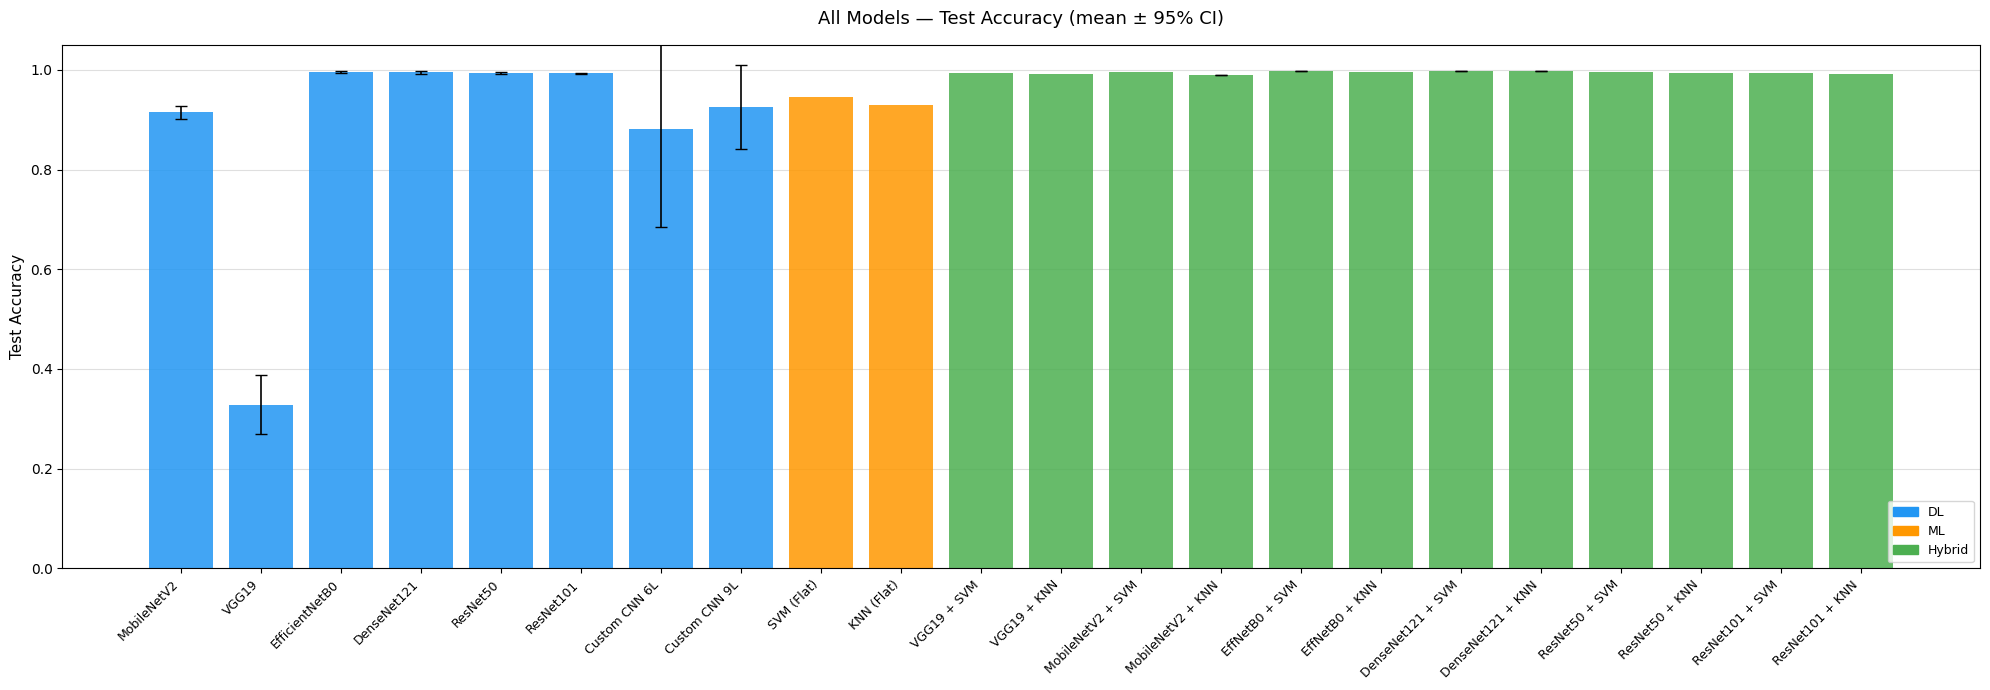

  Saved: D:\Mold Studies\Models\plots\comparison\comparison_accuracy.png


c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


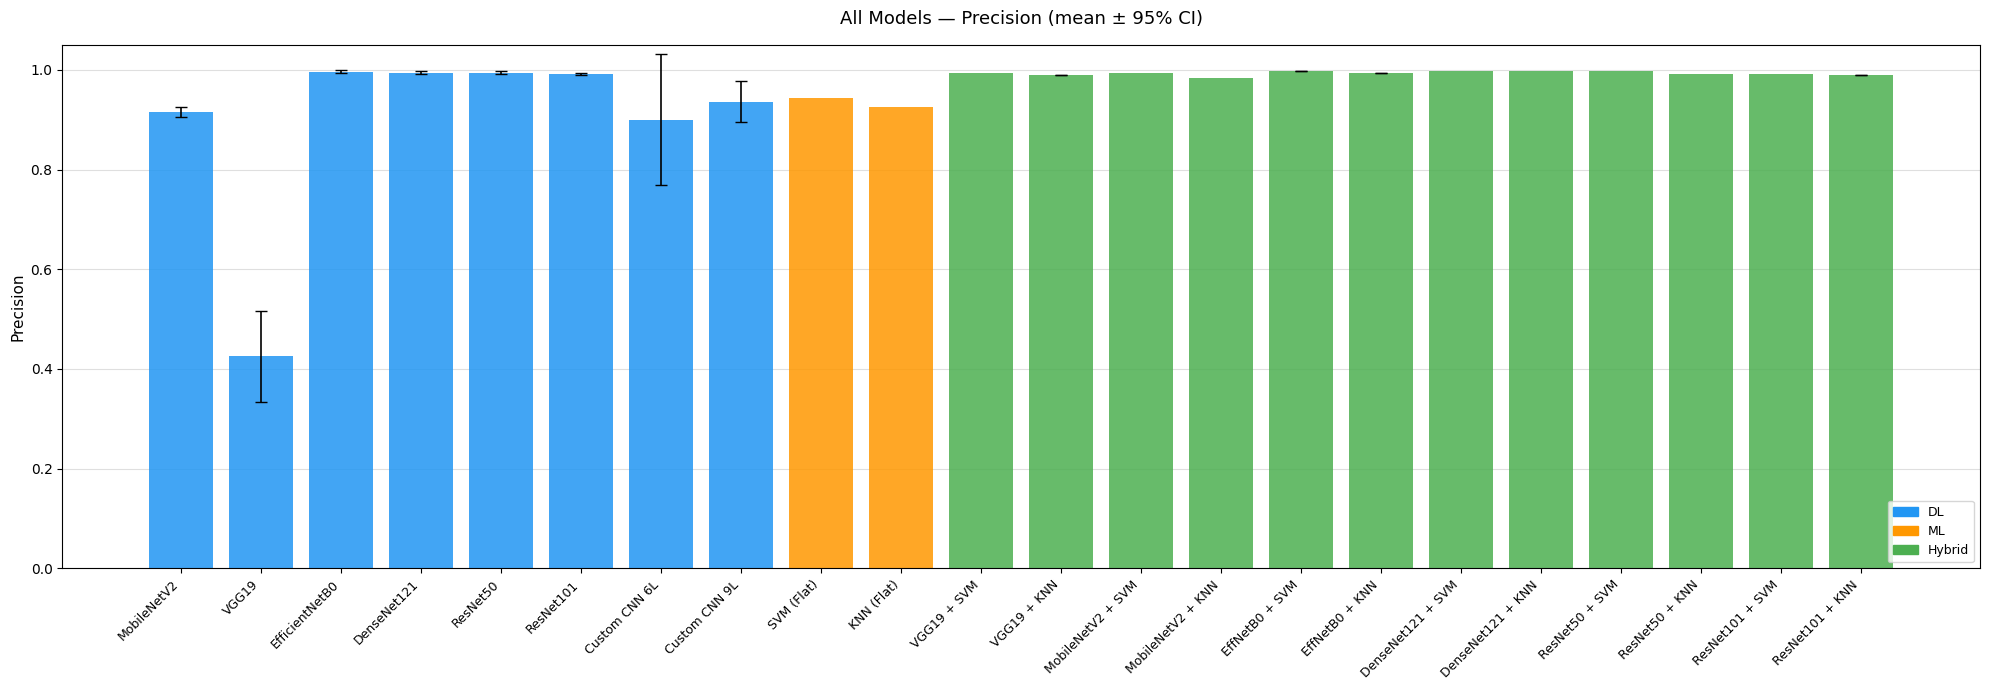

  Saved: D:\Mold Studies\Models\plots\comparison\comparison_precision.png


c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


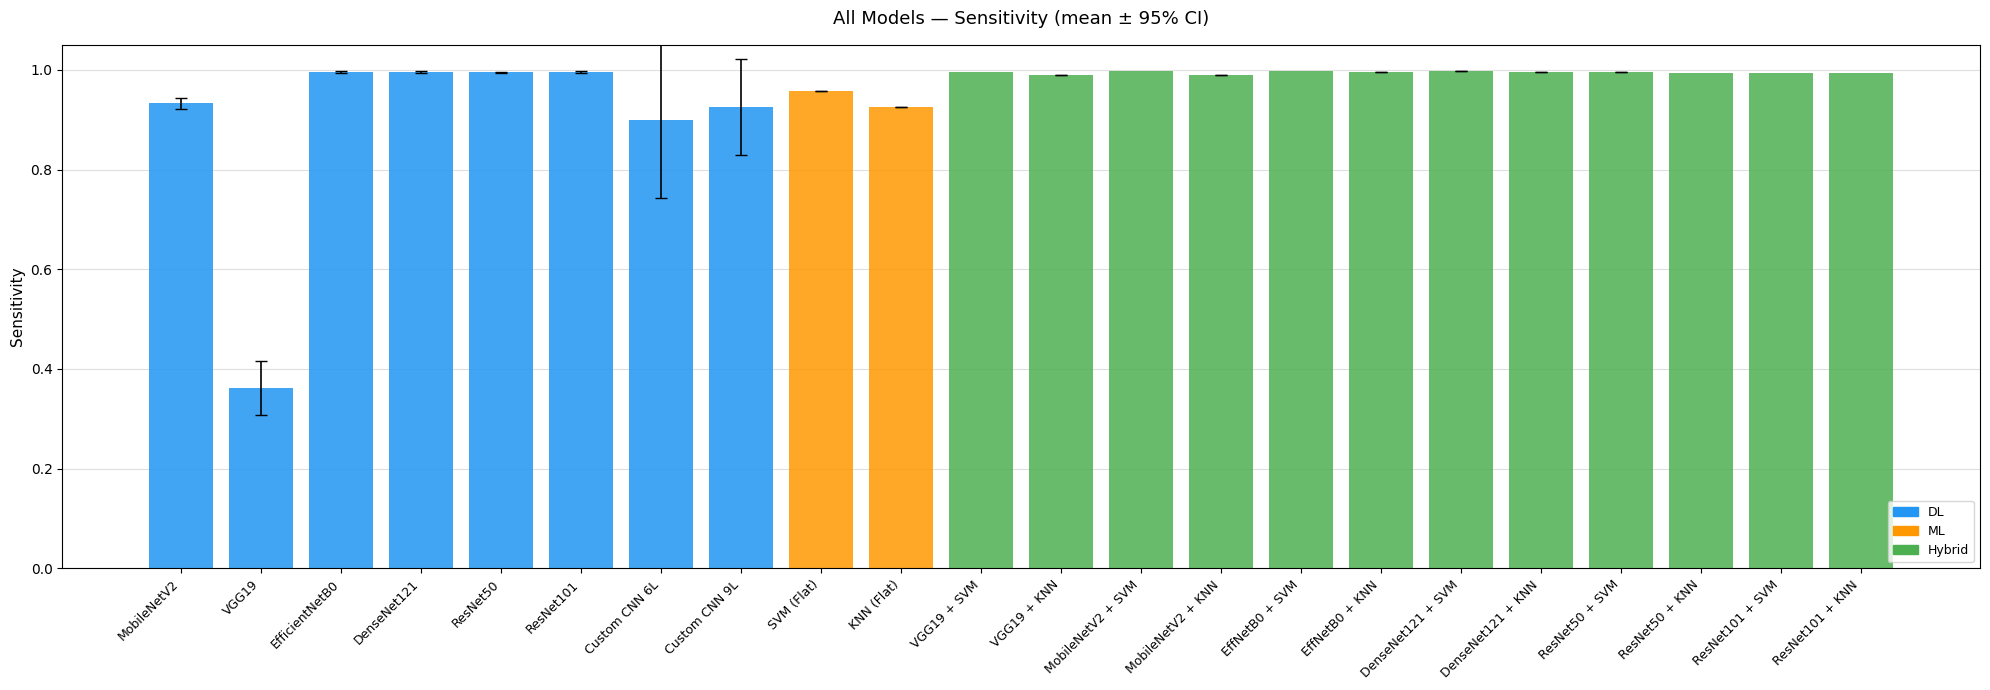

  Saved: D:\Mold Studies\Models\plots\comparison\comparison_sensitivity.png


c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


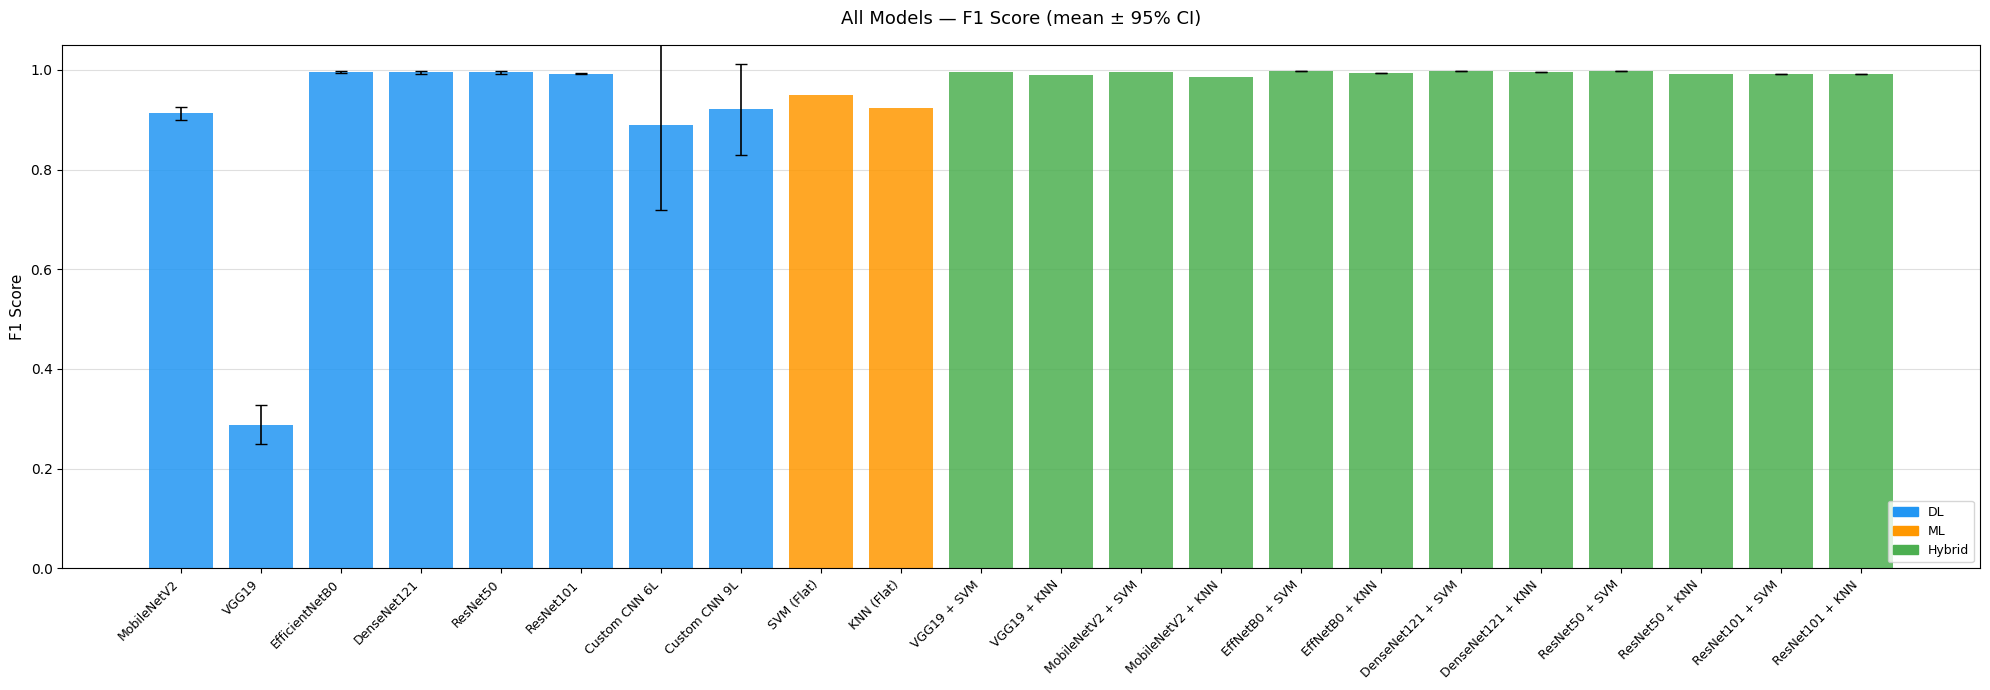

  Saved: D:\Mold Studies\Models\plots\comparison\comparison_f1.png


c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


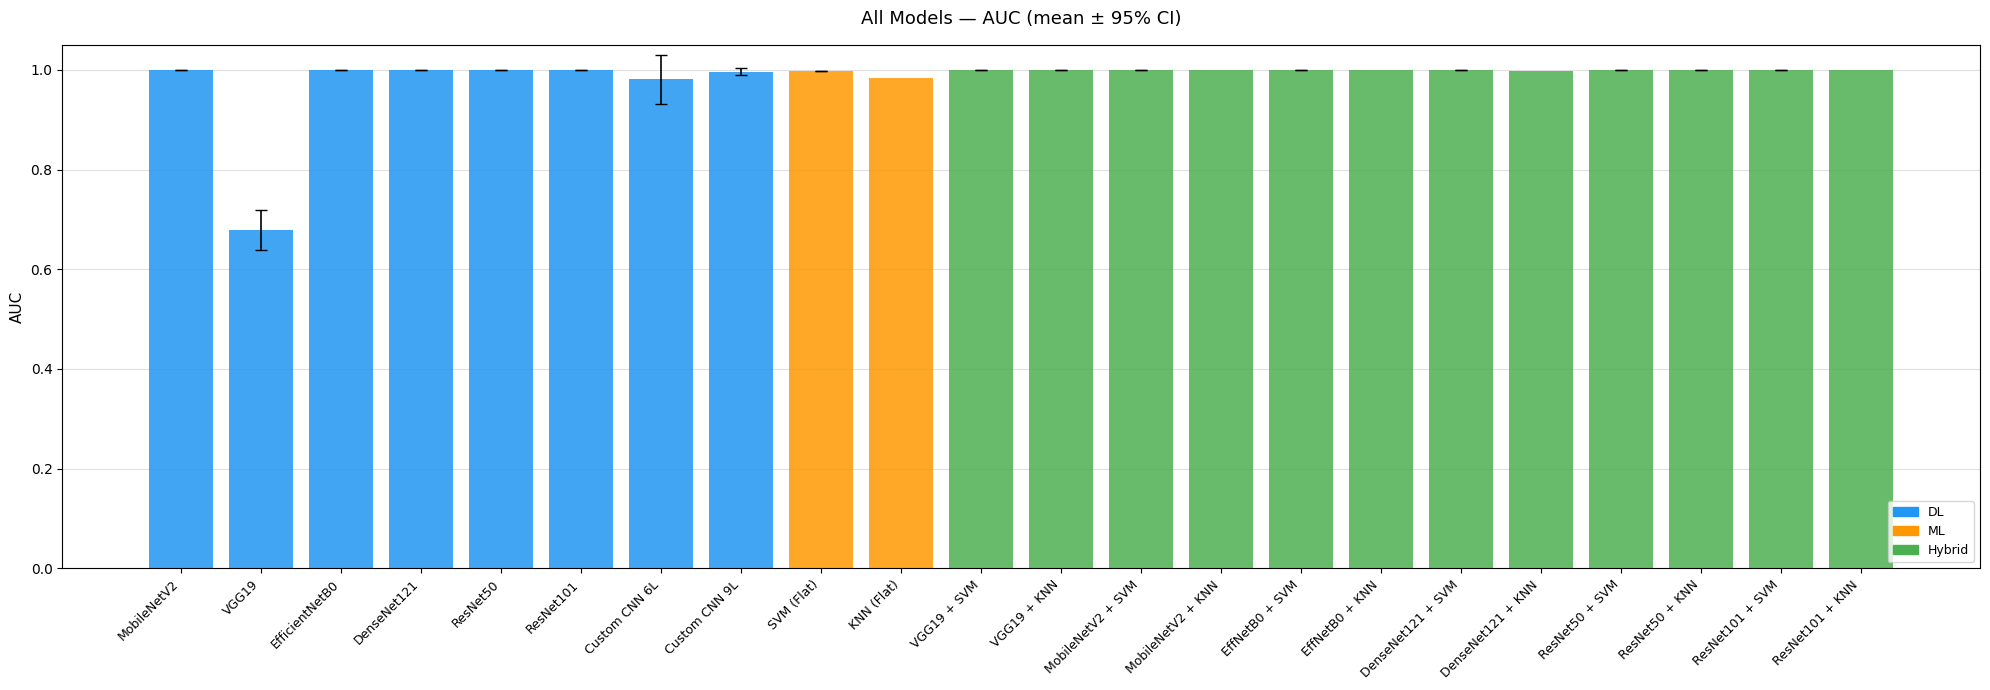

  Saved: D:\Mold Studies\Models\plots\comparison\comparison_auc.png

  Generating heatmap...


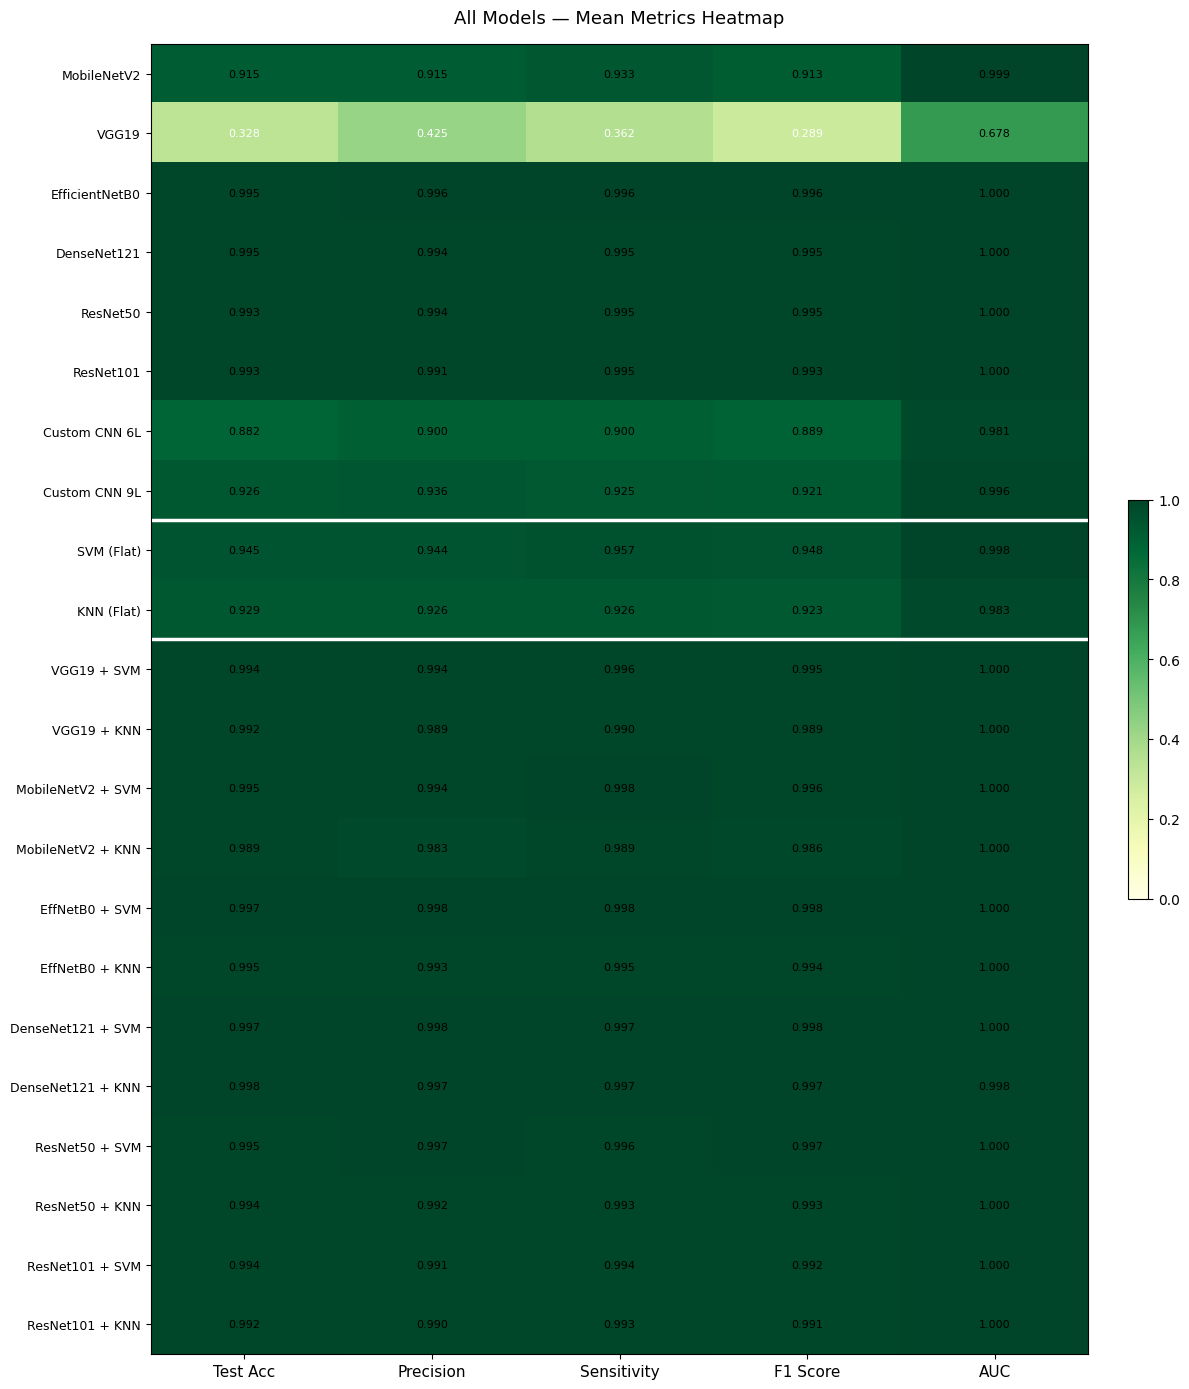

  Saved: D:\Mold Studies\Models\plots\comparison\comparison_heatmap.png

  Exporting summary CSV...
  Saved: D:\Mold Studies\Models\fragment5_model_comparison.csv

  ✓ Fragment 5 complete.
  All comparison plots saved to : D:\Mold Studies\Models\plots\comparison
  Summary CSV saved to          : D:\Mold Studies\Models\fragment5_model_comparison.csv


c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [11]:
"""
Fragment 5 — Grand Cross-Model Comparison
==========================================
Mould/Fruit Multiclass Classification — All Models

Compares all trained models across every pipeline:

  Deep Learning (End-to-End):
    MobileNetV2, VGG19, EfficientNetB0, DenseNet121,
    ResNet50, ResNet101, Custom CNN 6L, Custom CNN 9L

  Machine Learning (Flat Pixels):
    SVM (flat), KNN (flat)

  Hybrid (Feature Extraction + ML):
    VGG19 + SVM,       VGG19 + KNN
    MobileNetV2 + SVM, MobileNetV2 + KNN
    EfficientNetB0 + SVM, EfficientNetB0 + KNN
    DenseNet121 + SVM, DenseNet121 + KNN
    ResNet50 + SVM,    ResNet50 + KNN
    ResNet101 + SVM,   ResNet101 + KNN

Metrics reported per model:
    Test Accuracy, Precision, Sensitivity, F1 Score, AUC
    — mean, std, min, max, 95% CI across 5 runs
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import scipy.stats as stats

SAVE_DIR = r"D:\Mold Studies\Models"
PLOT_DIR = os.path.join(SAVE_DIR, "plots", "comparison")
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Step 1: Register all models ───────────────────────────────────────────────
# Each entry: (display_name, group, all_run_results, all_metrics)
# group: "DL" | "ML" | "Hybrid"

models = [

    # ── Deep Learning ──────────────────────────────────────────────────────
    ("MobileNetV2",         "DL",     mobilenetv2_all_run_results,
                                      mobilenetv2_all_metrics),
    ("VGG19",               "DL",     vgg19_all_run_results,
                                      vgg19_all_metrics),
    ("EfficientNetB0",      "DL",     efficientnetb0_all_run_results,
                                      efficientnetb0_all_metrics),
    ("DenseNet121",         "DL",     densenet121_all_run_results,
                                      densenet121_all_metrics),
    ("ResNet50",            "DL",     resnet50_all_run_results,
                                      resnet50_all_metrics),
    ("ResNet101",           "DL",     resnet101_all_run_results,
                                      resnet101_all_metrics),
    ("Custom CNN 6L",       "DL",     custom_cnn_all_run_results,
                                      custom_cnn_all_metrics),
    ("Custom CNN 9L",       "DL",     custom_cnn9_all_run_results,
                                      custom_cnn9_all_metrics),

    # ── ML Flat Pixels ─────────────────────────────────────────────────────
    ("SVM (Flat)",          "ML",     svm_flat_all_run_results,
                                      svm_flat_all_metrics),
    ("KNN (Flat)",          "ML",     knn_flat_all_run_results,
                                      knn_flat_all_metrics),

    # ── Hybrid ─────────────────────────────────────────────────────────────
    ("VGG19 + SVM",         "Hybrid", vgg19_svm_all_run_results,
                                      vgg19_svm_all_metrics),
    ("VGG19 + KNN",         "Hybrid", vgg19_knn_all_run_results,
                                      vgg19_knn_all_metrics),
    ("MobileNetV2 + SVM",   "Hybrid", mobilenetv2_svm_all_run_results,
                                      mobilenetv2_svm_all_metrics),
    ("MobileNetV2 + KNN",   "Hybrid", mobilenetv2_knn_all_run_results,
                                      mobilenetv2_knn_all_metrics),
    ("EffNetB0 + SVM",      "Hybrid", efficientnetb0_svm_all_run_results,
                                      efficientnetb0_svm_all_metrics),
    ("EffNetB0 + KNN",      "Hybrid", efficientnetb0_knn_all_run_results,
                                      efficientnetb0_knn_all_metrics),
    ("DenseNet121 + SVM",   "Hybrid", densenet121_svm_all_run_results,
                                      densenet121_svm_all_metrics),
    ("DenseNet121 + KNN",   "Hybrid", densenet121_knn_all_run_results,
                                      densenet121_knn_all_metrics),
    ("ResNet50 + SVM",      "Hybrid", resnet50_svm_all_run_results,
                                      resnet50_svm_all_metrics),
    ("ResNet50 + KNN",      "Hybrid", resnet50_knn_all_run_results,
                                      resnet50_knn_all_metrics),
    ("ResNet101 + SVM",     "Hybrid", resnet101_svm_all_run_results,
                                      resnet101_svm_all_metrics),
    ("ResNet101 + KNN",     "Hybrid", resnet101_knn_all_run_results,
                                      resnet101_knn_all_metrics),
]

# ── Step 2: Helper — extract per-run metric vectors ───────────────────────────

def get_metric_vals(run_results, metrics_list, metric_key):
    """
    Extracts per-run values for a given metric.
    DL models store accuracy/val_acc in run_results.
    All models store test metrics in metrics_list.
    """
    if metric_key == "accuracy":
        # test accuracy from metrics_list for all models
        return [m["accuracy"] for m in metrics_list]
    elif metric_key == "precision":
        return [m["macro_precision"] if "macro_precision" in m
                else m["precision"] for m in metrics_list]
    elif metric_key == "recall":
        return [m["macro_recall"] if "macro_recall" in m
                else m["recall"] for m in metrics_list]
    elif metric_key == "f1":
        return [m["macro_f1"] if "macro_f1" in m
                else m["f1"] for m in metrics_list]
    elif metric_key == "auc":
        return [np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])
                for m in metrics_list]


def ci95(vals):
    vals = np.array(vals)
    lo, hi = stats.t.interval(
        0.95,
        df    = len(vals) - 1,
        loc   = np.mean(vals),
        scale = stats.sem(vals)
    )
    return lo, hi

# ── Step 3: Per-Run Results Table ─────────────────────────────────────────────
# Shows all 5 individual run values per model per metric

METRICS = [
    ("Test Acc",    "accuracy"),
    ("Precision",   "precision"),
    ("Sensitivity", "recall"),
    ("F1 Score",    "f1"),
    ("AUC",         "auc"),
]

print("\n" + "=" * 110)
print("  FRAGMENT 5 — PER-RUN RESULTS (all 5 runs × all models)")
print("=" * 110)

for metric_label, metric_key in METRICS:

    col_model = 22
    col_run   = 10

    divider = "=" * (col_model + col_run * 5 + 6)
    thin    = "─" * (col_model + col_run * 5 + 6)

    print(f"\n  ── {metric_label} ──────────────────────────────────────────")
    print(divider)
    print(
        f"  {'Model':<{col_model}}"
        f"{'Run 1':>{col_run}}"
        f"{'Run 2':>{col_run}}"
        f"{'Run 3':>{col_run}}"
        f"{'Run 4':>{col_run}}"
        f"{'Run 5':>{col_run}}"
    )
    print(thin)

    prev_group = None
    for name, group, run_results, metrics_list in models:
        if group != prev_group and prev_group is not None:
            print(thin)
        prev_group = group

        vals = get_metric_vals(run_results, metrics_list, metric_key)
        row  = f"  {name:<{col_model}}"
        for v in vals:
            row += f"{v:>{col_run}.4f}"
        print(row)

    print(divider)

# ── Step 4: Statistical Summary Table ─────────────────────────────────────────

print("\n\n" + "=" * 120)
print("  FRAGMENT 5 — STATISTICAL SUMMARY (mean ± std, 95% CI across 5 runs)")
print("=" * 120)

col_model = 22
col_stat  = 10
col_ci    = 22

for metric_label, metric_key in METRICS:

    divider = "=" * (col_model + col_stat * 4 + col_ci + 6)
    thin    = "─" * (col_model + col_stat * 4 + col_ci + 6)

    print(f"\n  ── {metric_label} ──────────────────────────────────────────")
    print(divider)
    print(
        f"  {'Model':<{col_model}}"
        f"{'Mean':>{col_stat}}"
        f"{'Std':>{col_stat}}"
        f"{'Min':>{col_stat}}"
        f"{'Max':>{col_stat}}"
        f"{'95% CI':>{col_ci}}"
    )
    print(thin)

    prev_group = None
    for name, group, run_results, metrics_list in models:
        if group != prev_group and prev_group is not None:
            print(thin)
        prev_group = group

        vals = np.array(get_metric_vals(run_results, metrics_list, metric_key))
        mean = np.mean(vals)
        std  = np.std(vals)
        mn   = np.min(vals)
        mx   = np.max(vals)
        lo, hi = ci95(vals)

        print(
            f"  {name:<{col_model}}"
            f"{mean:>{col_stat}.4f}"
            f"{std:>{col_stat}.4f}"
            f"{mn:>{col_stat}.4f}"
            f"{mx:>{col_stat}.4f}"
            f"  [{lo:.4f}, {hi:.4f}]"
        )

    print(divider)

# ── Step 5: Best Model per Metric ─────────────────────────────────────────────

print("\n\n" + "=" * 60)
print("  BEST MODEL PER METRIC (by mean across 5 runs)")
print("=" * 60)

for metric_label, metric_key in METRICS:
    best_name  = None
    best_mean  = -1
    best_group = None

    for name, group, run_results, metrics_list in models:
        vals = np.array(get_metric_vals(run_results, metrics_list, metric_key))
        mean = np.mean(vals)
        if mean > best_mean:
            best_mean  = mean
            best_name  = name
            best_group = group

    print(f"  {metric_label:<14}: {best_name:<22} "
          f"({best_group})  mean={best_mean:.4f}")

print("=" * 60)

# ── Step 6: Visualisations ────────────────────────────────────────────────────

GROUP_COLORS = {
    "DL"    : "#2196F3",   # blue
    "ML"    : "#FF9800",   # orange
    "Hybrid": "#4CAF50",   # green
}

def bar_chart(metric_label, metric_key, filename):
    names  = [m[0] for m in models]
    groups = [m[1] for m in models]
    means  = []
    errs   = []

    for name, group, run_results, metrics_list in models:
        vals = np.array(get_metric_vals(run_results, metrics_list, metric_key))
        means.append(np.mean(vals))
        lo, hi = ci95(vals)
        errs.append((np.mean(vals) - lo, hi - np.mean(vals)))

    x      = np.arange(len(names))
    colors = [GROUP_COLORS[g] for g in groups]
    yerr   = np.array(errs).T

    fig, ax = plt.subplots(figsize=(20, 7))
    bars = ax.bar(x, means, color=colors, alpha=0.85,
                  yerr=yerr, capsize=4, error_kw={"elinewidth": 1.2})

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f"All Models — {metric_label} (mean ± 95% CI)",
                 fontsize=13, pad=15)
    ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    patches = [mpatches.Patch(color=c, label=g)
               for g, c in GROUP_COLORS.items()]
    ax.legend(handles=patches, loc="lower right", fontsize=9)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


print("\n  Generating bar charts...")
bar_chart("Test Accuracy",  "accuracy",  "comparison_accuracy.png")
bar_chart("Precision",      "precision", "comparison_precision.png")
bar_chart("Sensitivity",    "recall",    "comparison_sensitivity.png")
bar_chart("F1 Score",       "f1",        "comparison_f1.png")
bar_chart("AUC",            "auc",       "comparison_auc.png")

# ── Step 7: Heatmap — mean per metric per model ───────────────────────────────

print("\n  Generating heatmap...")

heatmap_data = []
row_labels   = [m[0] for m in models]

for name, group, run_results, metrics_list in models:
    row = []
    for metric_label, metric_key in METRICS:
        vals = np.array(get_metric_vals(run_results, metrics_list, metric_key))
        row.append(np.mean(vals))
    heatmap_data.append(row)

heatmap_arr = np.array(heatmap_data)
col_labels  = [m[0] for m in METRICS]

fig, ax = plt.subplots(figsize=(12, 14))
im = ax.imshow(heatmap_arr, aspect="auto", cmap="YlGn",
               vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title("All Models — Mean Metrics Heatmap", fontsize=13, pad=15)

for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val   = heatmap_arr[i, j]
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=8, color=color)

# Draw group separators
group_boundaries = []
prev = models[0][1]
for idx, (_, grp, _, _) in enumerate(models):
    if grp != prev:
        group_boundaries.append(idx - 0.5)
        prev = grp
for b in group_boundaries:
    ax.axhline(b, color="white", linewidth=2.5)

plt.tight_layout()
path = os.path.join(PLOT_DIR, "comparison_heatmap.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {path}")

# ── Step 8: Export summary to CSV ─────────────────────────────────────────────

print("\n  Exporting summary CSV...")

rows = []
for name, group, run_results, metrics_list in models:
    row = {"Model": name, "Group": group}
    for metric_label, metric_key in METRICS:
        vals   = np.array(get_metric_vals(run_results, metrics_list, metric_key))
        lo, hi = ci95(vals)
        row[f"{metric_label}_Mean"] = round(np.mean(vals), 4)
        row[f"{metric_label}_Std"]  = round(np.std(vals),  4)
        row[f"{metric_label}_Min"]  = round(np.min(vals),  4)
        row[f"{metric_label}_Max"]  = round(np.max(vals),  4)
        row[f"{metric_label}_CI_Lo"]= round(lo,             4)
        row[f"{metric_label}_CI_Hi"]= round(hi,             4)
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = os.path.join(SAVE_DIR, "fragment5_model_comparison.csv")
df.to_csv(csv_path, index=False)
print(f"  Saved: {csv_path}")

print("\n" + "=" * 60)
print("  ✓ Fragment 5 complete.")
print(f"  All comparison plots saved to : {PLOT_DIR}")
print(f"  Summary CSV saved to          : {csv_path}")
print("=" * 60)